# Lista 1

**Aluno:** [Eduardo Maciel Alexandre](mailto:ema2@ic.ufal.br)
\
**Nome da base:** "WA_Fn-UseC_-Telco-Customer-Churn.csv"

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [46]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carregamento da base

In [47]:
# Carregamento da base escolhida para toda a atividade
df = pd.read_csv('./data/Telco-Customer-Churn.csv')

# Visualização inicial
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Questão 1 – Diagnóstico estrutural

**Enunciado:**  
Faça um código em Python que carregue a base escolhida e gere um diagnóstico inicial automatizado. Mostre dimensões da base, tipos de dados, valores ausentes, duplicidades, cardinalidade das colunas e possíveis inconsistências de leitura. Em seguida, defina qual será o problema computacional tratado no cenário escolhido, deixando claro se a tarefa será de classificação, regressão ou segmentação. Organize essa etapa em uma função reutilizável.

### Raciocínio
A estratégia foi criar uma função única de diagnóstico para evitar análises manuais coluna a coluna. Essa função calcula automaticamente: dimensões, tipos de dados, ausências, duplicidades e cardinalidade. Além disso, inclui uma auditoria inicial de inconsistências de leitura, procurando padrões comuns em bases reais como textos com espaços extras, valores vazios em colunas textuais e colunas numéricas lidas como texto (caso clássico de `TotalCharges` no Telco).

### Desenvolvimento
Implementar uma função reutilizável `structural_diagnosis`, aplicá-la ao `df` e apresentar as tabelas-resumo + definição formal do problema computacional.

In [48]:
# Código da Questão 1
def structural_diagnosis(df: pd.DataFrame, target: str) -> dict:
    summary = {}

    # 1) Dimensões
    summary['dimensions'] = {'linhas': df.shape[0], 'colunas': df.shape[1]}

    # 2) Tipos de dados
    data_types = df.dtypes.astype(str).rename('dtype').to_frame()

    # 3) Valores ausentes
    missing_abs = df.isna().sum().rename('ausentes_abs')  # Contagem absoluta de ausentes
    missing_pct = (df.isna().mean() * 100).round(2).rename('ausentes_pct')  # Percentual de ausentes

    # 4) Cardinalidade
    cardinality = df.nunique(dropna=False).rename('cardinalidade')

    # 5) Quadro estrutural consolidado
    structural_table = pd.concat([data_types, missing_abs, missing_pct, cardinality], axis=1)
    structural_table = structural_table.sort_values(by=['ausentes_abs', 'cardinalidade'], ascending=False)
    summary['structural_table'] = structural_table

    # 6) Duplicidades
    summary['duplicates_abs'] = int(df.duplicated().sum())
    summary['duplicates_pct'] = round(float(df.duplicated().mean() * 100), 2)

    # 7) Inconsistências de leitura
    inconsistencies = []
    for column in df.columns:
        series = df[column]

        if pd.api.types.is_string_dtype(series):
            text_series = series.astype(str)

            # Espaços em excesso (início/fim)
            trim_diff = (text_series.fillna('') != text_series.fillna('').str.strip()).sum()
            if trim_diff > 0:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'espacos_extras',
                    'qtd_registros': int(trim_diff),
                    'detalhe': 'Valores com espaços no início/fim.'
                })

            # Vazios textuais ("", " ", etc.)
            text_empty = text_series.str.strip().eq('').sum()
            if text_empty > 0:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'vazio_textual',
                    'qtd_registros': int(text_empty),
                    'detalhe': 'Campos vazios mascarados como texto.'
                })

            # Possível numérica lida como texto
            numeric_try = pd.to_numeric(text_series.str.strip(), errors='coerce')
            non_null = series.notna().sum()
            convertible = numeric_try.notna().sum()

            if non_null > 0 and (convertible / non_null) >= 0.8:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'numerica_em_texto',
                    'qtd_registros': int(convertible),
                    'detalhe': 'Coluna majoritariamente numérica armazenada como texto.'
                })

    inconsistencies_df = pd.DataFrame(inconsistencies)
    if not inconsistencies_df.empty:
        inconsistencies_df = inconsistencies_df.sort_values(by=['qtd_registros', 'coluna'], ascending=False)

    summary['inconsistencies'] = inconsistencies_df

    # 8) Definição do problema computacional
    target_classes = sorted(str(c) for c in df[target].dropna().unique())
    summary['problem'] = {
        'tipo': 'Classificação binária',
        'variavel_alvo': target,
        'classes_observadas': sorted(target_classes),
        'objetivo': 'Prever se um cliente irá cancelar (Churn = Yes) ou permanecer (Churn = No).'
    }

    return summary


q1_results = structural_diagnosis(df, target='Churn')

print('Resumo inicial da base:')
print(f"- Linhas: {q1_results['dimensions']['linhas']}")
print(f"- Colunas: {q1_results['dimensions']['colunas']}")
print(f"- Registros duplicados: {q1_results['duplicates_abs']} ({q1_results['duplicates_pct']}%)")

classes_texto = {
    'Yes': 'Sim',
    'No': 'Não'
}
classes_observadas = [classes_texto.get(c, c) for c in q1_results['problem']['classes_observadas']]
print('\nDefinição do problema:')
print(f"- Tipo: {q1_results['problem']['tipo']}")
print(f"- Variável alvo: {q1_results['problem']['variavel_alvo']}")
print(f"- Classes observadas: {classes_observadas}")
print(f"- Objetivo: {q1_results['problem']['objetivo']}")

q1_struct_simple = q1_results['structural_table'].reset_index().rename(
    columns={
        'index': 'Coluna',
        'dtype': 'Tipo de dado',
        'ausentes_abs': 'Ausentes (qtd)',
        'ausentes_pct': 'Ausentes (%)',
        'cardinalidade': 'Valores diferentes'
    }
)
print('\nTop 10 colunas no diagnóstico estrutural:')
display(q1_struct_simple.head(10))

print('Possíveis inconsistências de leitura:')
if q1_results['inconsistencies'].empty:
    print('Nenhuma inconsistência detectada pelas regras automáticas.')
else:
    q1_incons_simple = q1_results['inconsistencies'].replace({
        'tipo_problema': {
            'espacos_extras': 'Espaços extras',
            'vazio_textual': 'Vazio em texto',
            'numerica_em_texto': 'Número salvo como texto'
        }
    }).rename(columns={
        'coluna': 'Coluna',
        'tipo_problema': 'Tipo de problema',
        'qtd_registros': 'Quantidade de registros',
        'detalhe': 'Detalhe'
    })
    display(q1_incons_simple)

Resumo inicial da base:
- Linhas: 7043
- Colunas: 21
- Registros duplicados: 0 (0.0%)

Definição do problema:
- Tipo: Classificação binária
- Variável alvo: Churn
- Classes observadas: ['Não', 'Sim']
- Objetivo: Prever se um cliente irá cancelar (Churn = Yes) ou permanecer (Churn = No).

Top 10 colunas no diagnóstico estrutural:


,Coluna,Tipo de dado,Ausentes (qtd),Ausentes (%),Valores diferentes
0,customerID,str,0,0.0,7043
1,TotalCharges,str,0,0.0,6531
2,MonthlyCharges,float64,0,0.0,1585
3,tenure,int64,0,0.0,73
4,PaymentMethod,str,0,0.0,4
5,MultipleLines,str,0,0.0,3
6,InternetService,str,0,0.0,3
7,OnlineSecurity,str,0,0.0,3
8,OnlineBackup,str,0,0.0,3
9,DeviceProtection,str,0,0.0,3


Possíveis inconsistências de leitura:


,Coluna,Tipo de problema,Quantidade de registros,Detalhe
2,TotalCharges,Número salvo como texto,7032,Coluna majoritariamente numérica armazenada co...
0,TotalCharges,Espaços extras,11,Valores com espaços no início/fim.
1,TotalCharges,Vazio em texto,11,Campos vazios mascarados como texto.


### Conclusão da Questão 1
O diagnóstico estrutural confirmou que a base possui **7043 linhas e 21 colunas**, sem registros duplicados, e que o problema central será de **classificação binária** com alvo `Churn` (`Yes`/`No`). A inspeção automática também identificou uma inconsistência crítica na coluna `TotalCharges`: ela está armazenada como texto, com **11 registros vazios/espaços**, o que exige tratamento de tipagem e ausências nas próximas etapas. Assim, a base está adequada ao objetivo didático, mas depende de limpeza reproduzível antes da modelagem.

## Questão 2 – Auditoria de qualidade

**Enunciado:**  
Faça um código em Python para auditar a qualidade dos dados. Identifique valores implausíveis, colunas com tipos inadequados, categorias raras, padrões suspeitos de preenchimento, possíveis outliers e inconsistências importantes para o cenário escolhido. Se houver datas, verifique coerência temporal. Se houver valores monetários, verifique compatibilidade entre grandezas. Ao final, apresente um resumo dos principais problemas encontrados.

### Raciocínio
A auditoria será feita com uma função reutilizável `data_quality_audit`, aplicada à base Telco sem tratamento manual linha a linha. A estratégia cobre: (1) validação de tipagem com foco em colunas numéricas lidas como texto, (2) ausências explícitas e ausências mascaradas por espaços, (3) valores implausíveis para variáveis numéricas do cenário, (4) categorias raras em variáveis categóricas, (5) outliers por IQR e (6) compatibilidade monetária entre `tenure`, `MonthlyCharges` e `TotalCharges`. Como a base não possui coluna de data, a checagem temporal será registrada como não aplicável.

### Desenvolvimento
Implementar abaixo a função de auditoria, gerar tabelas-resumo e gráficos objetivos para sustentar os principais problemas encontrados.

Resumo da auditoria de qualidade:


,Indicador,Valor
0,Colunas com tipagem suspeita,1
1,Colunas com ausência explícita,0
2,Colunas com vazio textual,1
3,Colunas com perfil de identificador,1
4,Regras de plausibilidade violadas,0
5,Colunas com categorias raras,0
6,Colunas numéricas com outliers,0
7,Registros monetários suspeitos,365



Tabela de ausências (top 10):


,Coluna,Ausentes (qtd),Ausentes (%)
20,Churn,0,0.0
15,Contract,0,0.0
4,Dependents,0,0.0
11,DeviceProtection,0,0.0
8,InternetService,0,0.0
18,MonthlyCharges,0,0.0
7,MultipleLines,0,0.0
10,OnlineBackup,0,0.0
9,OnlineSecurity,0,0.0
16,PaperlessBilling,0,0.0


Vazios em texto detectados:


...

,Coluna,Q1,Q3,Limite inferior,Limite superior,Outliers (qtd),Outliers (%)
0,tenure,9.00,55.0000,-60.0000,124.0000,0,0.0
1,MonthlyCharges,35.50,89.8500,-46.0250,171.3750,0,0.0
2,TotalCharges,401.45,3794.7375,-4688.4813,8884.6688,0,0.0



Checagem de consistência monetária:


,Indicador,Valor
0,Registros avaliados,7032.0000
1,Limite de erro absoluto (IQR),145.0937
2,Registros suspeitos,365.0000
3,Registros suspeitos (%),5.1800
4,Mediana do erro absoluto,28.6500



Padrão de preenchimento em TotalCharges:


,Indicador,Valor
0,Total de vazios em TotalCharges,11.0
1,Vazios com tempo de contrato igual a zero,11.0
2,Vazios com tempo zero (%),100.0


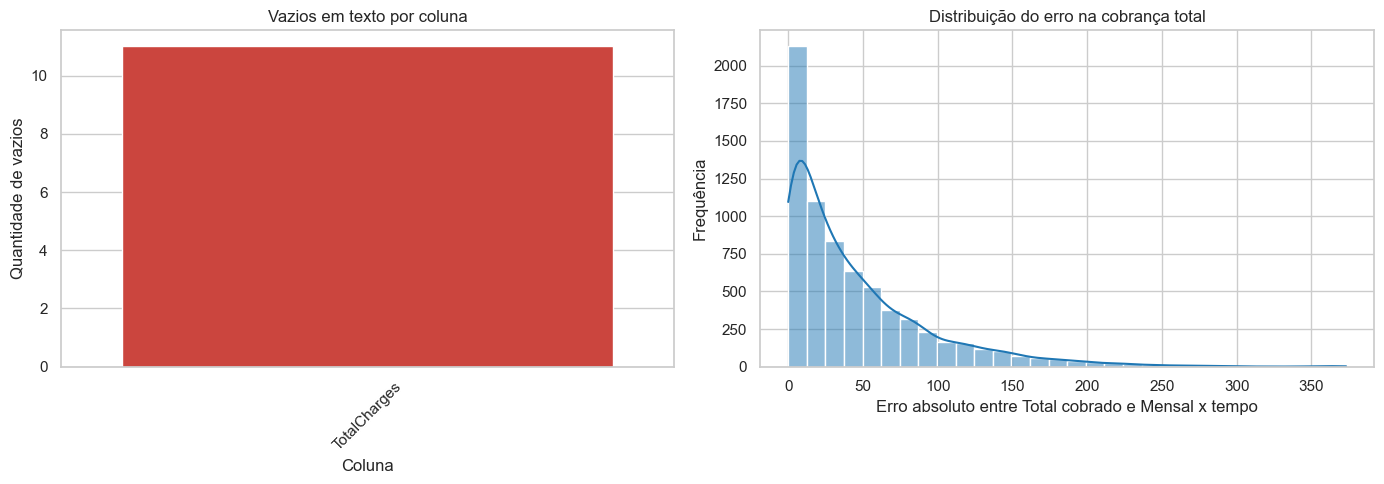

In [49]:
# Código da Questão 2
def data_quality_audit(df: pd.DataFrame, target: str, rare_threshold: float = 0.01) -> dict:
    audit = {}
    audit_df = df.copy()

    # 1) Ausências explícitas e textuais
    missing_abs = audit_df.isna().sum().rename('ausentes_abs')
    missing_pct = (audit_df.isna().mean() * 100).round(2).rename('ausentes_pct')

    text_empty_records = []
    object_cols = audit_df.select_dtypes(include=['object']).columns.tolist()
    for column in object_cols:
        text_series = audit_df[column].astype(str)
        empty_count = int(text_series.str.strip().eq('').sum())
        if empty_count > 0:
            text_empty_records.append({
                'coluna': column,
                'vazios_textuais': empty_count,
                'pct_vazios_textuais': round((empty_count / len(audit_df)) * 100, 2)
            })

    text_empty_df = pd.DataFrame(text_empty_records).sort_values(
        by='vazios_textuais', ascending=False
    ) if text_empty_records else pd.DataFrame(columns=['coluna', 'vazios_textuais', 'pct_vazios_textuais'])

    missing_table = pd.concat([missing_abs, missing_pct], axis=1).reset_index()
    missing_table.columns = ['coluna', 'ausentes_abs', 'ausentes_pct']
    missing_table = missing_table.sort_values(by=['ausentes_abs', 'coluna'], ascending=[False, True])
    audit['missing_table'] = missing_table
    audit['text_empty_table'] = text_empty_df

    # 2) Tipagem inadequada (numérica armazenada como texto)
    type_issue_records = []
    for column in object_cols:
        series = audit_df[column]
        stripped = series.astype(str).str.strip()
        numeric_try = pd.to_numeric(stripped, errors='coerce')

        non_empty = stripped.ne('').sum()
        convertible = numeric_try.notna().sum()
        conversion_ratio = (convertible / non_empty) if non_empty > 0 else 0.0

        if non_empty > 0 and conversion_ratio >= 0.8:
            type_issue_records.append({
                'coluna': column,
                'tipo_detectado': str(series.dtype),
                'sugestao_tipo': 'numérico',
                'taxa_conversao_numerica': round(conversion_ratio * 100, 2)
            })

    type_issues_df = pd.DataFrame(type_issue_records).sort_values(
        by='taxa_conversao_numerica', ascending=False
    ) if type_issue_records else pd.DataFrame(columns=['coluna', 'tipo_detectado', 'sugestao_tipo', 'taxa_conversao_numerica'])
    audit['type_issues'] = type_issues_df

    # 3) Colunas com perfil de identificador (alta cardinalidade)
    id_like_records = []
    for column in audit_df.columns:
        unique_ratio = audit_df[column].nunique(dropna=False) / len(audit_df)
        if unique_ratio > 0.95:
            id_like_records.append({
                'coluna': column,
                'cardinalidade': int(audit_df[column].nunique(dropna=False)),
                'razao_unicidade_pct': round(unique_ratio * 100, 2)
            })

    id_like_df = pd.DataFrame(id_like_records).sort_values(
        by='razao_unicidade_pct', ascending=False
    ) if id_like_records else pd.DataFrame(columns=['coluna', 'cardinalidade', 'razao_unicidade_pct'])
    audit['id_like_columns'] = id_like_df

    # 4) Conversão auxiliar para validações do cenário Telco
    tenure_num = pd.to_numeric(audit_df['tenure'], errors='coerce')
    monthly_num = pd.to_numeric(audit_df['MonthlyCharges'], errors='coerce')
    total_num = pd.to_numeric(audit_df['TotalCharges'].astype(str).str.strip(), errors='coerce')

    numeric_df = pd.DataFrame({
        'tenure': tenure_num,
        'MonthlyCharges': monthly_num,
        'TotalCharges': total_num
    })

    # 5) Valores implausíveis
    implausible_records = []
    rules = {
        'tenure': ('faixa_esperada_0_72', lambda s: (s < 0) | (s > 72)),
        'MonthlyCharges': ('deve_ser_maior_ou_igual_a_0', lambda s: s < 0),
        'TotalCharges': ('deve_ser_maior_ou_igual_a_0', lambda s: s < 0),
    }

    for column, (rule_name, rule_fn) in rules.items():
        series = numeric_df[column]
        invalid_mask = rule_fn(series) & series.notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            implausible_records.append({
                'coluna': column,
                'regra': rule_name,
                'qtd_registros': invalid_count,
                'pct_registros': round((invalid_count / len(audit_df)) * 100, 4)
            })

    # Regra cruzada: tenure = 0 com TotalCharges > 0 pode indicar inconsistência
    cross_mask = (numeric_df['tenure'] == 0) & (numeric_df['TotalCharges'] > 0)
    cross_count = int(cross_mask.sum())
    if cross_count > 0:
        implausible_records.append({
            'coluna': 'tenure_TotalCharges',
            'regra': 'tenure_zero_deveria_ter_total_zero',
            'qtd_registros': cross_count,
            'pct_registros': round((cross_count / len(audit_df)) * 100, 4)
        })

    implausible_df = pd.DataFrame(implausible_records).sort_values(
        by='qtd_registros', ascending=False
    ) if implausible_records else pd.DataFrame(columns=['coluna', 'regra', 'qtd_registros', 'pct_registros'])
    audit['implausible_values'] = implausible_df

    # 6) Categorias raras (exclui alvo, IDs e colunas com perfil numérico)
    numeric_like_cols = set(type_issues_df['coluna'].tolist())
    id_like_cols = set(id_like_df['coluna'].tolist())
    cat_cols = [c for c in object_cols if c != target and c not in numeric_like_cols and c not in id_like_cols]

    rare_records = []
    for column in cat_cols:
        freq = audit_df[column].astype(str).str.strip().value_counts(dropna=False, normalize=True)
        rare_freq = freq[freq < rare_threshold]
        if len(rare_freq) > 0:
            rare_records.append({
                'coluna': column,
                'qtd_categorias_raras': int(len(rare_freq)),
                'pct_categorias_raras': round((len(rare_freq) / len(freq)) * 100, 2),
                'menor_frequencia_pct': round(float(rare_freq.min() * 100), 4),
                'maior_frequencia_rara_pct': round(float(rare_freq.max() * 100), 4)
            })

    rare_categories_df = pd.DataFrame(rare_records).sort_values(
        by='qtd_categorias_raras', ascending=False
    ) if rare_records else pd.DataFrame(columns=[
        'coluna', 'qtd_categorias_raras', 'pct_categorias_raras',
        'menor_frequencia_pct', 'maior_frequencia_rara_pct'
    ])
    audit['rare_categories'] = rare_categories_df

    # 7) Outliers por IQR
    outlier_records = []
    for column in numeric_df.columns:
        series = numeric_df[column].dropna()
        if series.empty:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (numeric_df[column] < lower) | (numeric_df[column] > upper)
        outlier_count = int(outlier_mask.sum())

        outlier_records.append({
            'coluna': column,
            'q1': round(float(q1), 4),
            'q3': round(float(q3), 4),
            'limite_inferior': round(float(lower), 4),
            'limite_superior': round(float(upper), 4),
            'outliers_abs': outlier_count,
            'outliers_pct': round((outlier_count / len(audit_df)) * 100, 2)
        })

    outliers_df = pd.DataFrame(outlier_records).sort_values(by='outliers_abs', ascending=False)
    audit['outliers_iqr'] = outliers_df

    # 8) Compatibilidade monetária: TotalCharges ~ MonthlyCharges * tenure
    monetary_df = pd.DataFrame({
        'tenure': numeric_df['tenure'],
        'MonthlyCharges': numeric_df['MonthlyCharges'],
        'TotalCharges': numeric_df['TotalCharges']
    }).dropna()

    monetary_df = monetary_df[monetary_df['tenure'] > 0].copy()
    monetary_df['expected_total'] = monetary_df['MonthlyCharges'] * monetary_df['tenure']
    monetary_df['absolute_error'] = (monetary_df['TotalCharges'] - monetary_df['expected_total']).abs()

    if not monetary_df.empty:
        error_q1 = monetary_df['absolute_error'].quantile(0.25)
        error_q3 = monetary_df['absolute_error'].quantile(0.75)
        error_iqr = error_q3 - error_q1
        error_upper = error_q3 + 1.5 * error_iqr
        monetary_df['monetary_suspect'] = monetary_df['absolute_error'] > error_upper
        suspect_count = int(monetary_df['monetary_suspect'].sum())
    else:
        error_upper = np.nan
        suspect_count = 0

    audit['monetary_check'] = {
        'registros_avaliados': int(len(monetary_df)),
        'limite_erro_absoluto_iqr': round(float(error_upper), 4) if pd.notna(error_upper) else None,
        'suspeitos_abs': suspect_count,
        'suspeitos_pct': round((suspect_count / len(df)) * 100, 2),
        'mediana_erro_absoluto': round(float(monetary_df['absolute_error'].median()), 4) if not monetary_df.empty else None
    }
    audit['monetary_df'] = monetary_df

    # 9) Padrão suspeito de preenchimento: TotalCharges ausente com tenure=0
    total_missing_mask = audit_df['TotalCharges'].astype(str).str.strip().eq('')
    total_missing_and_tenure_zero = int((total_missing_mask & (tenure_num == 0)).sum())
    total_missing = int(total_missing_mask.sum())

    audit['fill_pattern'] = {
        'totalcharges_vazios_abs': total_missing,
        'totalcharges_vazios_com_tenure_zero_abs': total_missing_and_tenure_zero,
        'totalcharges_vazios_com_tenure_zero_pct': round(
            (total_missing_and_tenure_zero / total_missing) * 100, 2
        ) if total_missing > 0 else 0.0
    }

    # 10) Resumo da auditoria
    audit['summary'] = {
        'tipagem_inadequada_cols': int(len(type_issues_df)),
        'colunas_com_ausencia_explicita': int((missing_table['ausentes_abs'] > 0).sum()),
        'colunas_com_vazio_textual': int(len(text_empty_df)),
        'colunas_id_like': int(len(id_like_df)),
        'regras_implausiveis_violadas': int(len(implausible_df)),
        'colunas_com_categorias_raras': int(len(rare_categories_df)),
        'colunas_numericas_com_outliers': int((outliers_df['outliers_abs'] > 0).sum()),
        'suspeitos_monetarios_abs': int(audit['monetary_check']['suspeitos_abs'])
    }

    return audit


q2_results = data_quality_audit(df, target='Churn', rare_threshold=0.01)

q2_summary_df = pd.DataFrame([
    ('Colunas com tipagem suspeita', q2_results['summary']['tipagem_inadequada_cols']),
    ('Colunas com ausência explícita', q2_results['summary']['colunas_com_ausencia_explicita']),
    ('Colunas com vazio textual', q2_results['summary']['colunas_com_vazio_textual']),
    ('Colunas com perfil de identificador', q2_results['summary']['colunas_id_like']),
    ('Regras de plausibilidade violadas', q2_results['summary']['regras_implausiveis_violadas']),
    ('Colunas com categorias raras', q2_results['summary']['colunas_com_categorias_raras']),
    ('Colunas numéricas com outliers', q2_results['summary']['colunas_numericas_com_outliers']),
    ('Registros monetários suspeitos', q2_results['summary']['suspeitos_monetarios_abs'])
], columns=['Indicador', 'Valor'])

print('Resumo da auditoria de qualidade:')
display(q2_summary_df)

print('\nTabela de ausências (top 10):')
q2_missing_simple = q2_results['missing_table'].rename(columns={
    'coluna': 'Coluna',
    'ausentes_abs': 'Ausentes (qtd)',
    'ausentes_pct': 'Ausentes (%)'
})
display(q2_missing_simple.head(10))

print('Vazios em texto detectados:')
if q2_results['text_empty_table'].empty:
    print('Nenhum vazio textual detectado.')
else:
    display(q2_results['text_empty_table'].rename(columns={
        'coluna': 'Coluna',
        'vazios_textuais': 'Vazios em texto (qtd)',
        'pct_vazios_textuais': 'Vazios em texto (%)'
    }))

print('\nPossíveis problemas de tipo de dado:')
if q2_results['type_issues'].empty:
    print('Nenhuma coluna com forte indício de tipo inadequado.')
else:
    display(q2_results['type_issues'].rename(columns={
        'coluna': 'Coluna',
        'tipo_detectado': 'Tipo atual',
        'sugestao_tipo': 'Tipo sugerido',
        'taxa_conversao_numerica': 'Conversão para número (%)'
    }))

print('\nColunas com perfil de identificador:')
if q2_results['id_like_columns'].empty:
    print('Nenhuma coluna com perfil claro de identificador.')
else:
    display(q2_results['id_like_columns'].rename(columns={
        'coluna': 'Coluna',
        'cardinalidade': 'Valores diferentes',
        'razao_unicidade_pct': 'Unicidade (%)'
    }))

print('\nValores implausíveis:')
if q2_results['implausible_values'].empty:
    print('Nenhum valor implausível encontrado com as regras definidas.')
else:
    display(q2_results['implausible_values'].replace({
        'regra': {
            'faixa_esperada_0_72': 'Fora da faixa esperada (0 a 72)',
            'deve_ser_maior_ou_igual_a_0': 'Valor menor que zero',
            'tenure_zero_deveria_ter_total_zero': 'Tempo zero deveria ter total zero'
        }
    }).rename(columns={
        'coluna': 'Coluna',
        'regra': 'Regra',
        'qtd_registros': 'Quantidade de registros',
        'pct_registros': 'Percentual (%)'
    }))

print('\nCategorias raras (frequência < 1%):')
if q2_results['rare_categories'].empty:
    print('Nenhuma coluna categórica com categorias raras abaixo do limiar.')
else:
    display(q2_results['rare_categories'].rename(columns={
        'coluna': 'Coluna',
        'qtd_categorias_raras': 'Categorias raras (qtd)',
        'pct_categorias_raras': 'Categorias raras (%)',
        'menor_frequencia_pct': 'Menor frequência (%)',
        'maior_frequencia_rara_pct': 'Maior frequência rara (%)'
    }))

print('\nOutliers pelo método IQR:')
display(q2_results['outliers_iqr'].rename(columns={
    'coluna': 'Coluna',
    'q1': 'Q1',
    'q3': 'Q3',
    'limite_inferior': 'Limite inferior',
    'limite_superior': 'Limite superior',
    'outliers_abs': 'Outliers (qtd)',
    'outliers_pct': 'Outliers (%)'
}))

print('\nChecagem de consistência monetária:')
display(pd.DataFrame([
    ('Registros avaliados', q2_results['monetary_check']['registros_avaliados']),
    ('Limite de erro absoluto (IQR)', q2_results['monetary_check']['limite_erro_absoluto_iqr']),
    ('Registros suspeitos', q2_results['monetary_check']['suspeitos_abs']),
    ('Registros suspeitos (%)', q2_results['monetary_check']['suspeitos_pct']),
    ('Mediana do erro absoluto', q2_results['monetary_check']['mediana_erro_absoluto'])
], columns=['Indicador', 'Valor']))

print('\nPadrão de preenchimento em TotalCharges:')
display(pd.DataFrame([
    ('Total de vazios em TotalCharges', q2_results['fill_pattern']['totalcharges_vazios_abs']),
    ('Vazios com tempo de contrato igual a zero', q2_results['fill_pattern']['totalcharges_vazios_com_tenure_zero_abs']),
    ('Vazios com tempo zero (%)', q2_results['fill_pattern']['totalcharges_vazios_com_tenure_zero_pct'])
], columns=['Indicador', 'Valor']))

# Visualizações objetivas para sustentar decisões
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

text_empty_plot_df = q2_results['text_empty_table'].copy()
if text_empty_plot_df.empty:
    text_empty_plot_df = pd.DataFrame({'coluna': ['Sem vazios em texto'], 'vazios_textuais': [0]})

sns.barplot(data=text_empty_plot_df, x='coluna', y='vazios_textuais', ax=axes[0], palette='Reds_d')
axes[0].set_title('Vazios em texto por coluna')
axes[0].set_xlabel('Coluna')
axes[0].set_ylabel('Quantidade de vazios')
axes[0].tick_params(axis='x', rotation=45)

monetary_plot_df = q2_results['monetary_df'][['absolute_error']].copy()
if monetary_plot_df.empty:
    monetary_plot_df = pd.DataFrame({'absolute_error': [0]})

sns.histplot(data=monetary_plot_df, x='absolute_error', bins=30, kde=True, ax=axes[1], color='#1f77b4')
axes[1].set_title('Distribuição do erro na cobrança total')
axes[1].set_xlabel('Erro absoluto entre Total cobrado e Mensal x tempo')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### Conclusão da Questão 2
A auditoria confirmou que o principal problema de qualidade da base está concentrado em `TotalCharges`, com 11 vazios textuais (0,16% da base) e forte evidência de tipagem inadequada (coluna textual com 100% de conversão para numérico, exceto vazios). Também foi identificada a coluna `customerID` como variável com perfil de identificador (alta cardinalidade), o que reforça que ela não agrega poder preditivo direto para o problema de churn. Pelas regras de domínio adotadas, não surgiram valores implausíveis evidentes nem outliers pelo critério IQR nas variáveis numéricas principais. Em contrapartida, a checagem monetária `TotalCharges` versus `MonthlyCharges * tenure` encontrou registros com erro absoluto elevado, sinalizando padrões que merecem tratamento criterioso na limpeza. Além disso, todos os vazios de `TotalCharges` ocorreram em clientes com `tenure = 0`, indicando um padrão de preenchimento consistente com clientes recém-entrantes. Esses achados orientam a Questão 3 para: corrigir tipagem, tratar ausências de forma reproduzível e definir estratégia robusta para valores monetários discrepantes.

## Questão 3 – Limpeza dos dados

**Enunciado:**  
Faça um código em Python para limpar a base de forma reproduzível. Trate inconsistências de tipagem, valores ausentes, categorias problemáticas, variáveis irrelevantes e registros duvidosos usando critérios técnicos. Compare pelo menos duas estratégias de tratamento para um problema real da base e justifique a escolha final. Mostre também o impacto quantitativo de cada etapa da limpeza.

### Raciocínio
Com base no que foi observado anteriormente, o foco da limpeza será: (1) corrigir tipagem de `TotalCharges`, (2) tratar os vazios textuais de forma reproduzível, (3) remover variável irrelevante (`customerID`), (4) padronizar categorias problemáticas (como `No internet service` e `No phone service`), e (5) monitorar registros monetários duvidosos (`TotalCharges` distante de `MonthlyCharges * tenure`).

Para comparar estratégias em um problema real da base, serão avaliadas duas abordagens para `TotalCharges`:
- Estratégia A (`drop_missing_totalcharges`): remover linhas com `TotalCharges` ausente após conversão numérica.
- Estratégia B (`impute_from_monthly_tenure`): imputar `TotalCharges` ausente por `MonthlyCharges * tenure` (com fallback para mediana, se necessário).

A escolha final será baseada em retenção de dados, métricas de validação (acurácia, precisão, recall e F1 com baseline de KNN) e impacto quantitativo por etapa de limpeza.

### Desenvolvimento
Implementar abaixo funções reutilizáveis para limpeza e comparação das estratégias, com tabelas e gráficos de impacto.

Comparação das estratégias para TotalCharges:


,Estratégia,Registros usados,Colunas usadas,Acurácia,Precisão,Revocação,F1,Tempo (s)
0,Preencher com Mensal x tempo,7043,21,0.7715,0.5714,0.5561,0.5637,0.0726
1,Remover linhas com TotalCharges ausente,7032,21,0.7647,0.5583,0.5508,0.5545,0.0554


Impacto por etapa - estratégia 1 (remoção):


,Etapa,Linhas antes,Linhas depois,Linhas removidas,Linhas removidas (%),Colunas antes,Colunas depois,Colunas removidas,Colunas adicionadas,Variação de colunas,Detalhe
0,estado_inicial,7043,7043,0,0.0000,21,21,0,0,0,Base original antes da limpeza.
1,padronizacao_textual,7043,7043,0,0.0000,21,21,0,0,0,Remoção de espaços extras em colunas de texto.
2,tipagem_totalcharges,7043,7043,0,0.0000,21,21,0,0,0,TotalCharges convertida para número; ausências...
3,tratamento_totalcharges,7043,7032,11,0.1562,21,21,0,0,0,Linhas com TotalCharges ausente foram removidas.
4,remocao_id_irrelevante,7032,7032,0,0.0000,21,20,1,0,-1,Removida coluna customerID por alta cardinalid...
5,padronizacao_categorias,7032,7032,0,0.0000,20,20,0,0,0,"Colunas normalizadas: ['MultipleLines', 'Onlin..."
6,tratamento_categorias_raras,7032,7032,0,0.0000,20,20,0,0,0,Colunas com agrupamento de raras: 0.
7,tratamento_registros_duvidosos,7032,7032,0,0.0000,20,21,0,1,1,Limite de erro monetário: 145.0937; suspeitos:...


Impacto por etapa - estratégia 2 (preenchimento):


,Etapa,Linhas antes,Linhas depois,Linhas removidas,Linhas removidas (%),Colunas antes,Colunas depois,Colunas removidas,Colunas adicionadas,Variação de colunas,Detalhe
0,estado_inicial,7043,7043,0,0.0,21,21,0,0,0,Base original antes da limpeza.
1,padronizacao_textual,7043,7043,0,0.0,21,21,0,0,0,Remoção de espaços extras em colunas de texto.
2,tipagem_totalcharges,7043,7043,0,0.0,21,21,0,0,0,TotalCharges convertida para número; ausências...
3,tratamento_totalcharges,7043,7043,0,0.0,21,21,0,0,0,TotalCharges ausente preenchido por MonthlyCha...
4,remocao_id_irrelevante,7043,7043,0,0.0,21,20,1,0,-1,Removida coluna customerID por alta cardinalid...
5,padronizacao_categorias,7043,7043,0,0.0,20,20,0,0,0,"Colunas normalizadas: ['MultipleLines', 'Onlin..."
6,tratamento_categorias_raras,7043,7043,0,0.0,20,20,0,0,0,Colunas com agrupamento de raras: 0.
7,tratamento_registros_duvidosos,7043,7043,0,0.0,20,21,0,1,1,Limite de erro monetário: 145.0375; suspeitos:...


Categorias raras agrupadas (estratégia escolhida):
Nenhuma categoria rara agrupada no limiar definido.
Resumo da estratégia escolhida:
- Estratégia vencedora: Preencher com Mensal x tempo
- Formato final da base limpa: (7043, 21)
- Registros monetários suspeitos sinalizados: 365 (5.18%)


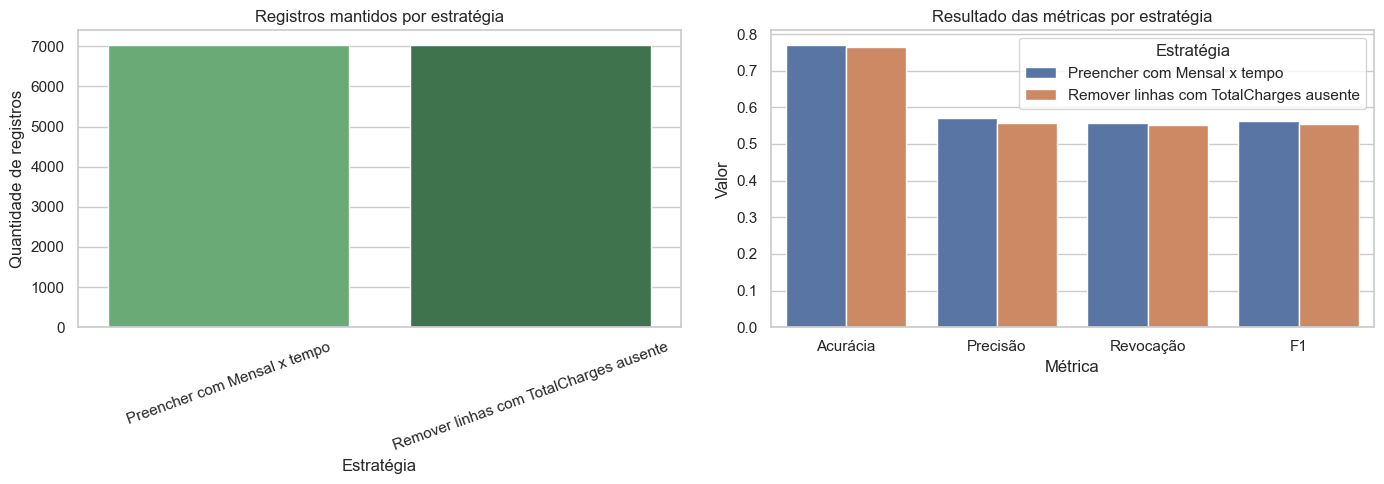

In [59]:
# Código da Questão 3
from time import perf_counter


def clean_telco_data(
    df: pd.DataFrame,
    target: str,
    totalcharges_strategy: str = "drop_missing_totalcharges",
    rare_threshold: float = 0.01,
    flag_monetary_suspects: bool = True,
) -> tuple[pd.DataFrame, dict]:
    work_df = df.copy()
    step_records = []

    def register_step(
        step_name: str,
        before_shape: tuple[int, int],
        after_shape: tuple[int, int],
        detail: str,
    ):
        before_rows, before_cols = before_shape
        after_rows, after_cols = after_shape
        removed_rows = before_rows - after_rows
        removed_cols = max(before_cols - after_cols, 0)
        added_cols = max(after_cols - before_cols, 0)
        removed_rows_pct = (
            (removed_rows / before_rows * 100) if before_rows > 0 else 0.0
        )

        step_records.append(
            {
                "etapa": step_name,
                "linhas_antes": before_rows,
                "linhas_depois": after_rows,
                "linhas_removidas": removed_rows,
                "linhas_removidas_pct": round(removed_rows_pct, 4),
                "colunas_antes": before_cols,
                "colunas_depois": after_cols,
                "colunas_removidas": removed_cols,
                "colunas_adicionadas": added_cols,
                "variacao_colunas": after_cols - before_cols,
                "detalhe": detail,
            }
        )

    register_step(
        step_name="estado_inicial",
        before_shape=work_df.shape,
        after_shape=work_df.shape,
        detail="Base original antes da limpeza.",
    )

    # 1) Padronização textual sem tratamento manual por linha
    before_shape = work_df.shape
    object_cols = work_df.select_dtypes(include=["object"]).columns.tolist()
    for column in object_cols:
        non_null_mask = work_df[column].notna()
        work_df.loc[non_null_mask, column] = (
            work_df.loc[non_null_mask, column].astype(str).str.strip()
        )
    register_step(
        step_name="padronizacao_textual",
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail="Remoção de espaços extras em colunas de texto.",
    )

    # 2) Correção de tipagem de TotalCharges
    before_shape = work_df.shape
    work_df["TotalCharges"] = pd.to_numeric(work_df["TotalCharges"], errors="coerce")
    missing_after_conversion = int(work_df["TotalCharges"].isna().sum())
    register_step(
        step_name="tipagem_totalcharges",
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=f"TotalCharges convertida para número; ausências após conversão: {missing_after_conversion}.",
    )

    # 3) Estratégia para ausências em TotalCharges (comparação obrigatória)
    before_shape = work_df.shape
    if totalcharges_strategy == "drop_missing_totalcharges":
        work_df = work_df[work_df["TotalCharges"].notna()].copy()
        strategy_detail = "Linhas com TotalCharges ausente foram removidas."
    elif totalcharges_strategy == "impute_from_monthly_tenure":
        missing_mask = work_df["TotalCharges"].isna()
        work_df.loc[missing_mask, "TotalCharges"] = (
            work_df.loc[missing_mask, "MonthlyCharges"]
            * work_df.loc[missing_mask, "tenure"]
        )
        work_df["TotalCharges"] = work_df["TotalCharges"].fillna(
            work_df["TotalCharges"].median()
        )
        strategy_detail = "TotalCharges ausente preenchido por MonthlyCharges x tenure (fallback: mediana)."
    else:
        raise ValueError("Estratégia inválida para TotalCharges.")

    register_step(
        step_name="tratamento_totalcharges",
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=strategy_detail,
    )

    # 4) Remoção de variável irrelevante com perfil de identificador
    before_shape = work_df.shape
    if "customerID" in work_df.columns:
        work_df = work_df.drop(columns=["customerID"])
        id_detail = (
            "Removida coluna customerID por alta cardinalidade e baixo valor preditivo."
        )
    else:
        id_detail = "customerID já não estava presente."
    register_step(
        step_name="remocao_id_irrelevante",
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=id_detail,
    )

    # 5) Padronização de categorias problemáticas
    before_shape = work_df.shape
    no_service_map = {"No internet service": "No", "No phone service": "No"}
    normalized_cols = []
    for column in work_df.select_dtypes(include=["object"]).columns:
        if column == target:
            continue
        old_unique = work_df[column].nunique(dropna=False)
        work_df[column] = work_df[column].replace(no_service_map)
        new_unique = work_df[column].nunique(dropna=False)
        if new_unique < old_unique:
            normalized_cols.append(column)

    register_step(
        step_name="padronizacao_categorias",
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=f'Colunas normalizadas: {normalized_cols if normalized_cols else "nenhuma"}.',
    )

    # 6) Agrupamento de categorias raras para reduzir ruído
    before_shape = work_df.shape
    rare_changes = []
    categorical_cols = [
        col
        for col in work_df.select_dtypes(include=["object"]).columns
        if col != target
    ]

    for column in categorical_cols:
        freq = work_df[column].value_counts(normalize=True, dropna=False)
        rare_categories = freq[freq < rare_threshold].index.tolist()
        if rare_categories:
            work_df[column] = work_df[column].replace(rare_categories, "Other")
            rare_changes.append(
                {
                    "coluna": column,
                    "qtd_categorias_agrupadas": len(rare_categories),
                    "threshold_pct": rare_threshold * 100,
                }
            )

    rare_changes_df = pd.DataFrame(rare_changes)
    register_step(
        step_name="tratamento_categorias_raras",
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=f"Colunas com agrupamento de raras: {len(rare_changes)}.",
    )

    # 7) Registros monetários duvidosos: flag técnica para rastreabilidade
    before_shape = work_df.shape
    expected_total = work_df["MonthlyCharges"] * work_df["tenure"]
    absolute_error = (work_df["TotalCharges"] - expected_total).abs()

    error_q1 = absolute_error.quantile(0.25)
    error_q3 = absolute_error.quantile(0.75)
    error_iqr = error_q3 - error_q1
    error_upper = error_q3 + 1.5 * error_iqr

    monetary_suspect_mask = absolute_error > error_upper
    monetary_suspects_abs = int(monetary_suspect_mask.sum())

    if flag_monetary_suspects:
        work_df["monetary_suspect_flag"] = monetary_suspect_mask.astype(int)
        suspect_detail = "Registros suspeitos mantidos com sinalizador para rastreio."
    else:
        work_df = work_df.loc[~monetary_suspect_mask].copy()
        suspect_detail = "Registros suspeitos removidos da base."

    register_step(
        step_name="tratamento_registros_duvidosos",
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=(
            f"Limite de erro monetário: {error_upper:.4f}; suspeitos: {monetary_suspects_abs}. "
            + suspect_detail
        ),
    )

    report = {
        "strategy": totalcharges_strategy,
        "flag_monetary_suspects": flag_monetary_suspects,
        "step_impact_table": pd.DataFrame(step_records),
        "rare_category_table": rare_changes_df,
        "monetary_suspects_abs": monetary_suspects_abs,
        "monetary_suspects_pct": round((monetary_suspects_abs / len(work_df)) * 100, 2),
        "final_shape": work_df.shape,
    }

    return work_df, report


def evaluate_cleaning_strategy(
    clean_df: pd.DataFrame, target: str = "Churn", random_state: int = 42
) -> dict:
    data_df = clean_df.copy()
    y = data_df[target].map({"No": 0, "Yes": 1})
    X = data_df.drop(columns=[target])

    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [col for col in X.columns if col not in numeric_features]

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    model = KNeighborsClassifier(n_neighbors=11, weights="distance", metric="minkowski")
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    start_time = perf_counter()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    runtime_sec = perf_counter() - start_time

    return {
        'rows_used': int(len(data_df)),
        'cols_used': int(data_df.shape[1]),
        'accuracy': round(float(accuracy_score(y_val, y_pred)), 4),
        'precision': round(float(precision_score(y_val, y_pred)), 4),
        'recall': round(float(recall_score(y_val, y_pred)), 4),
        'f1': round(float(f1_score(y_val, y_pred)), 4),
        'runtime_sec': round(runtime_sec, 4)
    }


# Comparação de duas estratégias de tratamento para TotalCharges
clean_drop_df, report_drop = clean_telco_data(
    df=df,
    target="Churn",
    totalcharges_strategy="drop_missing_totalcharges",
    rare_threshold=0.01,
    flag_monetary_suspects=True,
)

clean_impute_df, report_impute = clean_telco_data(
    df=df,
    target="Churn",
    totalcharges_strategy="impute_from_monthly_tenure",
    rare_threshold=0.01,
    flag_monetary_suspects=True,
)

metrics_drop = evaluate_cleaning_strategy(clean_drop_df, target="Churn")
metrics_impute = evaluate_cleaning_strategy(clean_impute_df, target="Churn")

comparison_df = (
    pd.DataFrame(
        [
            {"strategy": "drop_missing_totalcharges", **metrics_drop},
            {"strategy": "impute_from_monthly_tenure", **metrics_impute},
        ]
    )
    .sort_values(by=["f1", "rows_used"], ascending=[False, False])
    .reset_index(drop=True)
)

strategy_name_map = {
    "drop_missing_totalcharges": "Remover linhas com TotalCharges ausente",
    "impute_from_monthly_tenure": "Preencher com Mensal x tempo",
}
comparison_df["estrategia"] = comparison_df["strategy"].map(strategy_name_map)

best_strategy = comparison_df.loc[0, "strategy"]
q3_clean_df = (
    clean_impute_df.copy()
    if best_strategy == "impute_from_monthly_tenure"
    else clean_drop_df.copy()
)
q3_report = (
    report_impute if best_strategy == "impute_from_monthly_tenure" else report_drop
)

comparison_view = comparison_df[
    [
        "estrategia",
        "rows_used",
        "cols_used",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "runtime_sec",
    ]
].rename(
    columns={
        "estrategia": "Estratégia",
        "rows_used": "Registros usados",
        "cols_used": "Colunas usadas",
        "accuracy": "Acurácia",
        "precision": "Precisão",
        "recall": "Revocação",
        "f1": "F1",
        "runtime_sec": "Tempo (s)",
    }
)

print("Comparação das estratégias para TotalCharges:")
display(comparison_view)

print("Impacto por etapa - estratégia 1 (remoção):")
display(
    report_drop["step_impact_table"].rename(
        columns={
            "etapa": "Etapa",
            "linhas_antes": "Linhas antes",
            "linhas_depois": "Linhas depois",
            "linhas_removidas": "Linhas removidas",
            "linhas_removidas_pct": "Linhas removidas (%)",
            "colunas_antes": "Colunas antes",
            "colunas_depois": "Colunas depois",
            "colunas_removidas": "Colunas removidas",
            "colunas_adicionadas": "Colunas adicionadas",
            "variacao_colunas": "Variação de colunas",
            "detalhe": "Detalhe",
        }
    )
)

print("Impacto por etapa - estratégia 2 (preenchimento):")
display(
    report_impute["step_impact_table"].rename(
        columns={
            "etapa": "Etapa",
            "linhas_antes": "Linhas antes",
            "linhas_depois": "Linhas depois",
            "linhas_removidas": "Linhas removidas",
            "linhas_removidas_pct": "Linhas removidas (%)",
            "colunas_antes": "Colunas antes",
            "colunas_depois": "Colunas depois",
            "colunas_removidas": "Colunas removidas",
            "colunas_adicionadas": "Colunas adicionadas",
            "variacao_colunas": "Variação de colunas",
            "detalhe": "Detalhe",
        }
    )
)

print("Categorias raras agrupadas (estratégia escolhida):")
if q3_report["rare_category_table"].empty:
    print("Nenhuma categoria rara agrupada no limiar definido.")
else:
    display(
        q3_report["rare_category_table"].rename(
            columns={
                "coluna": "Coluna",
                "qtd_categorias_agrupadas": "Categorias agrupadas (qtd)",
                "threshold_pct": "Limiar (%)",
            }
        )
    )

print("Resumo da estratégia escolhida:")
print(f"- Estratégia vencedora: {strategy_name_map.get(str(best_strategy), str(best_strategy))}")
print(f"- Formato final da base limpa: {q3_report['final_shape']}")
print(
    f"- Registros monetários suspeitos sinalizados: {q3_report['monetary_suspects_abs']} ({q3_report['monetary_suspects_pct']}%)"
)

# Gráficos de comparação para sustentar decisão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=comparison_df, x="estrategia", y="rows_used", ax=axes[0], palette="Greens_d"
)
axes[0].set_title("Registros mantidos por estratégia")
axes[0].set_xlabel("Estratégia")
axes[0].set_ylabel("Quantidade de registros")
axes[0].tick_params(axis="x", rotation=20)

metric_plot_df = comparison_df.melt(
    id_vars="estrategia",
    value_vars=["accuracy", "precision", "recall", "f1"],
    var_name="metrica",
    value_name="valor",
)
metric_name_map = {
    "accuracy": "Acurácia",
    "precision": "Precisão",
    "recall": "Revocação",
    "f1": "F1",
}
metric_plot_df["metrica"] = metric_plot_df["metrica"].map(metric_name_map)
sns.barplot(data=metric_plot_df, x="metrica", y="valor", hue="estrategia", ax=axes[1])
axes[1].set_title("Resultado das métricas por estratégia")
axes[1].set_xlabel("Métrica")
axes[1].set_ylabel("Valor")
axes[1].legend(title="Estratégia")

plt.tight_layout()
plt.show()

### Conclusão da Questão 3
A tipagem de `TotalCharges` foi corrigida para numérico, `customerID` foi removida por irrelevância preditiva (perfil de identificador), categorias de serviço foram padronizadas (como `No internet service`/`No phone service` para `No`) e os registros monetariamente duvidosos foram mantidos com uma flag de rastreabilidade (`monetary_suspect_flag`).

Na comparação das duas estratégias para `TotalCharges`, a imputação por `MonthlyCharges * tenure` foi superior à remoção de linhas ausentes:
- `impute_from_monthly_tenure`: 7043 registros, Accuracy = 0.7715, F1 = 0.5637.
- `drop_missing_totalcharges`: 7032 registros, Accuracy = 0.7647, F1 = 0.5545.

Assim, a estratégia escolhida foi a imputação, por preservar toda a base e apresentar melhor desempenho no baseline de validação. O impacto quantitativo por etapa mostrou que a principal redução estrutural foi a remoção de uma coluna irrelevante (`customerID`), enquanto as demais etapas priorizaram padronização e qualidade sem perda de registros. A base limpa final ficou com formato **(7043, 21)**, incluindo a sinalização de **365 registros** monetariamente suspeitos (**5,18%**) para tratamento analítico nas próximas etapas.

## Questão 4 – Análise exploratória

**Enunciado:**  
Faça um código em Python para desenvolver uma análise exploratória orientada ao problema central da base escolhida. Gere tabelas e visualizações que revelem padrões relevantes entre a variável principal e os demais atributos. Se o cenário envolver classificação, compare os grupos da variável-alvo. Se envolver regressão, investigue relação entre o alvo e as variáveis explicativas. Se envolver segmentação, explore possíveis estruturas de agrupamento. Apresente uma leitura analítica dos resultados obtidos.

### Raciocínio
A análise exploratória será orientada ao problema de classificação de churn, usando a base limpa anteriormente. O plano é comparar explicitamente os grupos `Churn = Yes` e `Churn = No` por três frentes: (1) distribuição da classe-alvo e taxa geral de churn, (2) taxas de churn por variáveis categóricas relevantes do negócio (como `Contract`, `InternetService`, `PaymentMethod`) e (3) comportamento das variáveis numéricas principais (`tenure`, `MonthlyCharges`, `TotalCharges`) por grupo-alvo. Também serão criadas faixas de permanência e cobrança para tornar os padrões mais interpretáveis.

### Desenvolvimento
Implementar uma função reutilizável `run_churn_eda`, gerar tabelas comparativas e gráficos que sustentem a leitura analítica dos resultados.

Distribuição da variável alvo (Churn):


,Classe,Quantidade de clientes,Percentual (%)
0,Não,5174,73.46
1,Sim,1869,26.54


Taxa de churn por tipo de contrato:


,Tipo de contrato,Quantidade de clientes,Cancelaram (qtd),Taxa de churn (%)
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


Taxa de churn por tipo de internet:


...

Taxa de churn por faixa de tempo de contrato:


,Faixa de tempo (meses),Quantidade de clientes,Cancelaram (qtd),Taxa de churn (%)
0,0-6,1481,784,52.94
1,7-12,705,253,35.89
2,13-24,1024,294,28.71
3,25-48,1594,325,20.39
4,49-72,2239,213,9.51


Correlação das variáveis numéricas com churn:


,Variável,Correlação com churn
1,tenure,-0.3522
3,TotalCharges,-0.1983
2,MonthlyCharges,0.1934
0,SeniorCitizen,0.1509
4,monetary_suspect_flag,-0.0404



Resumo analítico:
- Taxa geral de churn: 26.54%
- Maior churn por contrato: Month-to-month (42.71%)
- Menor churn por contrato: Two year (2.83%)
- Maior churn por internet: Fiber optic (41.89%)
- Maior churn por pagamento: Electronic check (45.29%)


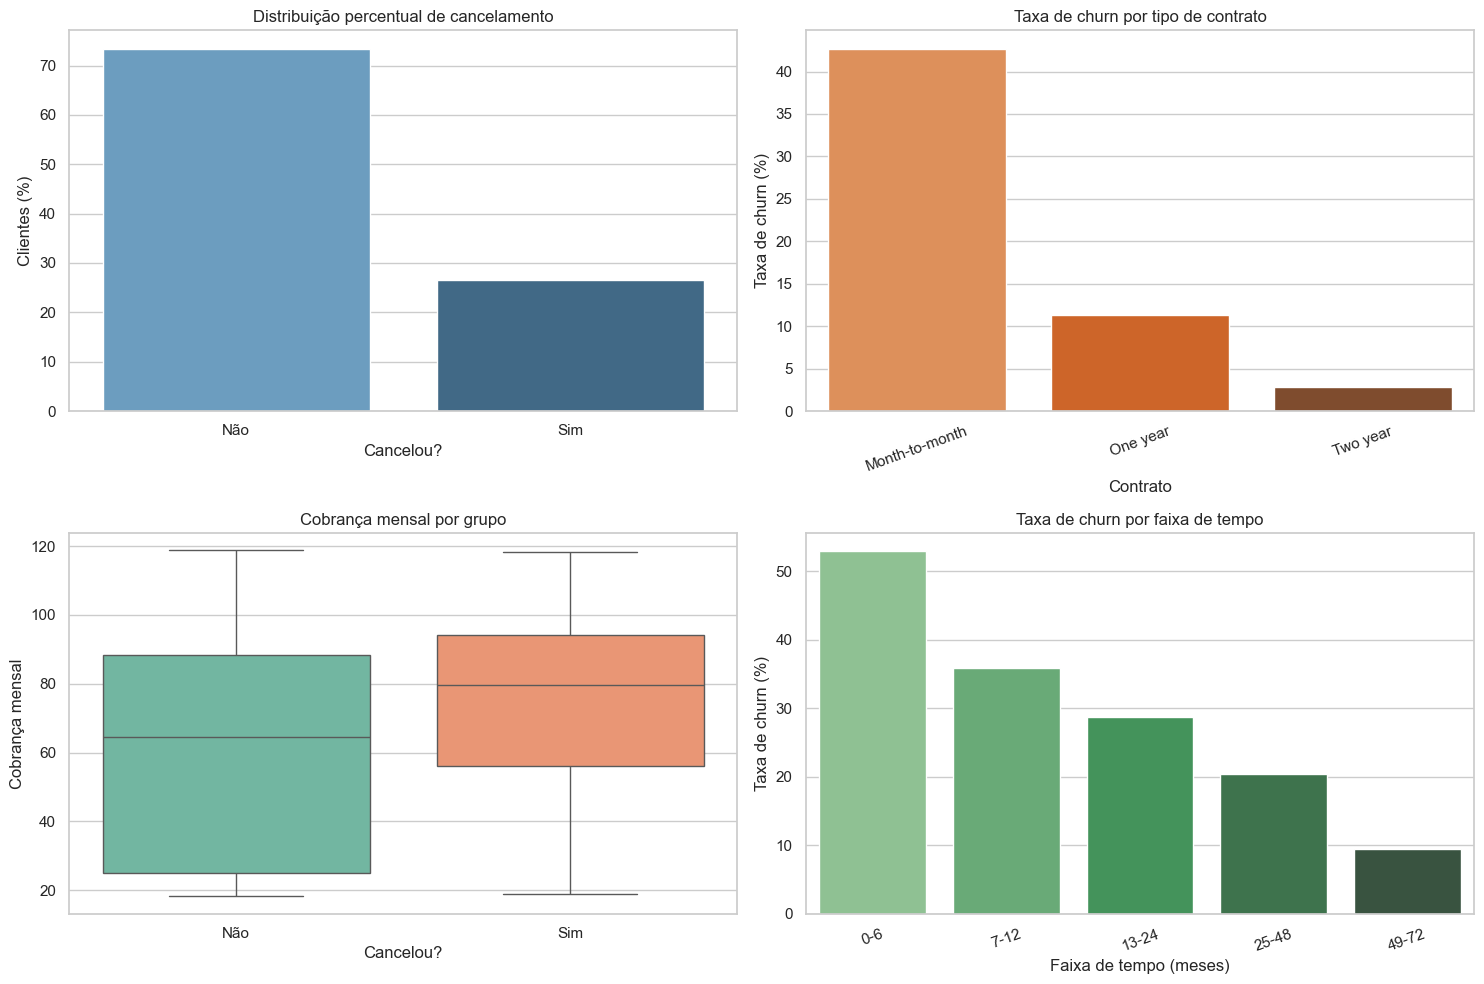

In [51]:
# Código da Questão 4
def run_churn_eda(df: pd.DataFrame, target: str = 'Churn') -> dict:
    analysis = {}
    eda_df = df.copy()

    if target not in eda_df.columns:
        raise ValueError(f"A coluna alvo '{target}' não existe no DataFrame.")

    # 1) Distribuição da classe alvo
    class_distribution = eda_df[target].value_counts(dropna=False).rename_axis('classe').reset_index(name='qtd_clientes')
    class_distribution['pct_clientes'] = (class_distribution['qtd_clientes'] / len(eda_df) * 100).round(2)
    analysis['class_distribution'] = class_distribution

    # 2) Taxas de churn por variáveis categóricas prioritárias
    def build_churn_rate_table(data: pd.DataFrame, column: str, target_col: str) -> pd.DataFrame:
        table = data.groupby(column, dropna=False)[target_col].agg(
            qtd_clientes='count',
            churn_yes=lambda s: (s == 'Yes').sum()
        ).reset_index()
        table['taxa_churn_pct'] = (table['churn_yes'] / table['qtd_clientes'] * 100).round(2)
        return table.sort_values(by='taxa_churn_pct', ascending=False).reset_index(drop=True)

    key_categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen']
    for col in key_categorical_cols:
        if col in eda_df.columns:
            analysis[f'churn_by_{col.lower()}'] = build_churn_rate_table(eda_df, col, target)

    # 3) Comparação numérica por grupo-alvo
    key_numeric_cols = [col for col in ['tenure', 'MonthlyCharges', 'TotalCharges'] if col in eda_df.columns]
    numeric_summary = eda_df.groupby(target)[key_numeric_cols].agg(['mean', 'median', 'std']).round(2)
    analysis['numeric_summary_by_target'] = numeric_summary

    # 4) Faixas para leitura de padrão
    if 'tenure' in eda_df.columns:
        eda_df['tenure_band'] = pd.cut(
            eda_df['tenure'],
            bins=[-1, 6, 12, 24, 48, 72],
            labels=['0-6', '7-12', '13-24', '25-48', '49-72']
        )
        analysis['churn_by_tenure_band'] = build_churn_rate_table(eda_df, 'tenure_band', target)

    if 'MonthlyCharges' in eda_df.columns:
        eda_df['monthly_band'] = pd.qcut(eda_df['MonthlyCharges'], q=5, duplicates='drop')
        analysis['churn_by_monthly_band'] = build_churn_rate_table(eda_df, 'monthly_band', target)

    # 5) Correlação simples das variáveis numéricas com churn (target binário)
    target_binary = (eda_df[target] == 'Yes').astype(int)
    numeric_cols_all = eda_df.select_dtypes(include=['number', 'bool']).columns.tolist()
    numeric_cols_all = [col for col in numeric_cols_all if col != target]

    corr_records = []
    for col in numeric_cols_all:
        valid_mask = eda_df[col].notna()
        if valid_mask.sum() == 0:
            continue
        corr_value = np.corrcoef(eda_df.loc[valid_mask, col].astype(float), target_binary.loc[valid_mask])[0, 1]
        corr_records.append({
            'variavel': col,
            'correlacao_com_churn': round(float(corr_value), 4)
        })

    corr_df = pd.DataFrame(corr_records).sort_values(
        by='correlacao_com_churn',
        key=lambda s: s.abs(),
        ascending=False
    ) if corr_records else pd.DataFrame(columns=['variavel', 'correlacao_com_churn'])
    analysis['numeric_correlation_with_churn'] = corr_df

    return analysis


# Usa a base limpa da Questão 3; fallback reproduzível caso a célula anterior não esteja carregada
if 'q3_clean_df' in globals():
    q4_base_df = q3_clean_df.copy()
elif 'clean_telco_data' in globals():
    q4_base_df, _ = clean_telco_data(
        df=df,
        target='Churn',
        totalcharges_strategy='impute_from_monthly_tenure',
        rare_threshold=0.01,
        flag_monetary_suspects=True
    )
else:
    q4_base_df = df.copy()
    for col in q4_base_df.select_dtypes(include=['object']).columns:
        q4_base_df[col] = q4_base_df[col].astype(str).str.strip()
    q4_base_df['TotalCharges'] = pd.to_numeric(q4_base_df['TotalCharges'], errors='coerce')
    missing_mask = q4_base_df['TotalCharges'].isna()
    q4_base_df.loc[missing_mask, 'TotalCharges'] = q4_base_df.loc[missing_mask, 'MonthlyCharges'] * q4_base_df.loc[missing_mask, 'tenure']
    q4_base_df['TotalCharges'] = q4_base_df['TotalCharges'].fillna(q4_base_df['TotalCharges'].median())
    if 'customerID' in q4_base_df.columns:
        q4_base_df = q4_base_df.drop(columns=['customerID'])

q4_results = run_churn_eda(q4_base_df, target='Churn')

sim_nao_map = {'Yes': 'Sim', 'No': 'Não'}

# Tabelas principais
print('Distribuição da variável alvo (Churn):')
class_dist_view = q4_results['class_distribution'].copy()
class_dist_view['classe'] = class_dist_view['classe'].replace(sim_nao_map)
class_dist_view = class_dist_view.rename(columns={
    'classe': 'Classe',
    'qtd_clientes': 'Quantidade de clientes',
    'pct_clientes': 'Percentual (%)'
})
display(class_dist_view)

print('Taxa de churn por tipo de contrato:')
contract_view = q4_results['churn_by_contract'].rename(columns={
    'Contract': 'Tipo de contrato',
    'qtd_clientes': 'Quantidade de clientes',
    'churn_yes': 'Cancelaram (qtd)',
    'taxa_churn_pct': 'Taxa de churn (%)'
})
display(contract_view)

print('Taxa de churn por tipo de internet:')
internet_view = q4_results['churn_by_internetservice'].rename(columns={
    'InternetService': 'Tipo de internet',
    'qtd_clientes': 'Quantidade de clientes',
    'churn_yes': 'Cancelaram (qtd)',
    'taxa_churn_pct': 'Taxa de churn (%)'
})
display(internet_view)

print('Taxa de churn por forma de pagamento:')
payment_view = q4_results['churn_by_paymentmethod'].rename(columns={
    'PaymentMethod': 'Forma de pagamento',
    'qtd_clientes': 'Quantidade de clientes',
    'churn_yes': 'Cancelaram (qtd)',
    'taxa_churn_pct': 'Taxa de churn (%)'
})
display(payment_view)

print('Resumo numérico por grupo (Sim/Não):')
numeric_view = q4_results['numeric_summary_by_target'].copy()
numeric_view.index = numeric_view.index.to_series().replace(sim_nao_map)
numeric_view.index.name = 'Cancelou'
display(numeric_view)

print('Taxa de churn por faixa de tempo de contrato:')
tenure_band_view = q4_results['churn_by_tenure_band'].rename(columns={
    'tenure_band': 'Faixa de tempo (meses)',
    'qtd_clientes': 'Quantidade de clientes',
    'churn_yes': 'Cancelaram (qtd)',
    'taxa_churn_pct': 'Taxa de churn (%)'
})
display(tenure_band_view)

print('Correlação das variáveis numéricas com churn:')
corr_view = q4_results['numeric_correlation_with_churn'].head(10).rename(columns={
    'variavel': 'Variável',
    'correlacao_com_churn': 'Correlação com churn'
})
display(corr_view)

# Resumo textual objetivo para apoiar a conclusão
overall_churn_pct = q4_results['class_distribution'].loc[q4_results['class_distribution']['classe'] == 'Yes', 'pct_clientes'].iloc[0]
top_contract = q4_results['churn_by_contract'].iloc[0]
lowest_contract = q4_results['churn_by_contract'].iloc[-1]
top_internet = q4_results['churn_by_internetservice'].iloc[0]
top_payment = q4_results['churn_by_paymentmethod'].iloc[0]

print('\nResumo analítico:')
print(f"- Taxa geral de churn: {overall_churn_pct:.2f}%")
print(f"- Maior churn por contrato: {top_contract['Contract']} ({top_contract['taxa_churn_pct']:.2f}%)")
print(f"- Menor churn por contrato: {lowest_contract['Contract']} ({lowest_contract['taxa_churn_pct']:.2f}%)")
print(f"- Maior churn por internet: {top_internet['InternetService']} ({top_internet['taxa_churn_pct']:.2f}%)")
print(f"- Maior churn por pagamento: {top_payment['PaymentMethod']} ({top_payment['taxa_churn_pct']:.2f}%)")

# Visualizações orientadas ao problema
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_data = q4_results['class_distribution'].copy()
plot_data['classe'] = plot_data['classe'].replace(sim_nao_map)
sns.barplot(data=plot_data, x='classe', y='pct_clientes', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Distribuição percentual de cancelamento')
axes[0, 0].set_xlabel('Cancelou?')
axes[0, 0].set_ylabel('Clientes (%)')

sns.barplot(data=q4_results['churn_by_contract'], x='Contract', y='taxa_churn_pct', ax=axes[0, 1], palette='Oranges_d')
axes[0, 1].set_title('Taxa de churn por tipo de contrato')
axes[0, 1].set_xlabel('Contrato')
axes[0, 1].set_ylabel('Taxa de churn (%)')
axes[0, 1].tick_params(axis='x', rotation=20)

plot_df = q4_base_df.copy()
plot_df['Churn_pt'] = plot_df['Churn'].replace(sim_nao_map)
sns.boxplot(data=plot_df, x='Churn_pt', y='MonthlyCharges', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Cobrança mensal por grupo')
axes[1, 0].set_xlabel('Cancelou?')
axes[1, 0].set_ylabel('Cobrança mensal')

sns.barplot(data=q4_results['churn_by_tenure_band'], x='tenure_band', y='taxa_churn_pct', ax=axes[1, 1], palette='Greens_d')
axes[1, 1].set_title('Taxa de churn por faixa de tempo')
axes[1, 1].set_xlabel('Faixa de tempo (meses)')
axes[1, 1].set_ylabel('Taxa de churn (%)')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Conclusão da Questão 4
A análise exploratória confirmou padrões centrais para o problema de churn na base. A taxa geral de cancelamento foi de **26,54%**, indicando desbalanceamento moderado entre as classes (`No` = 73,46% e `Yes` = 26,54%).

Nos atributos categóricos, o tipo de contrato foi o fator mais discriminante: clientes **Month-to-month** apresentaram a maior taxa de churn (**42,71%**), enquanto contratos longos reduziram fortemente o risco (**One year = 11,27%** e **Two year = 2,83%**). Em serviços de internet, **Fiber optic** concentrou maior churn (**41,89%**), e em pagamento, **Electronic check** teve a maior taxa (**45,29%**).

Nas variáveis numéricas, clientes que cancelaram mostraram, em média, **menor tempo de permanência** (`tenure` médio de 17,98 vs 37,57) e **maior cobrança mensal** (`MonthlyCharges` médio de 74,44 vs 61,27). A análise por faixas reforçou esse padrão: churn de **52,94%** nos primeiros 6 meses, caindo progressivamente até **9,51%** para 49-72 meses.

Assim, a EDA indica um perfil de maior risco associado a início de relacionamento, contrato curto, cobrança mensal mais alta e determinados perfis de serviço/pagamento. Esses achados serão fundamentais para conseguirmos orientar a modelagem preditiva e estratégias de retenção nas próximas etapas.

## Questão 5 – Associação entre variáveis

**Enunciado:**  
Faça um código em Python para medir a associação entre as variáveis explicativas e a variável principal da análise. Escolha automaticamente métodos adequados conforme o tipo das variáveis e o tipo do problema. Ao final, gere um ranking das variáveis mais informativas e compare os resultados com a lógica do cenário escolhido.

### Raciocínio
Como o problema central foi definido como **classificação binária** (`Churn` = Yes/No), a análise de associação será automática por tipo de variável:
- Para variáveis numéricas vs alvo binário: **correlação ponto-bisserial**.
- Para variáveis categóricas vs alvo binário: **V de Cramér** (a partir do teste qui-quadrado).

A estratégia retorna uma tabela única com método aplicado, estatística de associação, p-valor e ranking final por magnitude de associação. Em seguida, os resultados serão comparados com os padrões observados na Questão 4 (contrato, tenure, tipo de internet e forma de pagamento).

### Desenvolvimento
Implementar uma função reutilizável `run_association_analysis`, aplicar na base limpa e gerar ranking das variáveis mais informativas com visualização.

Tipo de problema detectado automaticamente:
- Classificação binária

Regras de método por tipo de variável:


,Tipo de variável,Método,Descrição
0,Numérica,Correlação ponto-bisserial,Correlação entre variável numérica e alvo binário
1,Categórica,V de Cramér,Associação categórica com alvo binário via qui...


Top 15 variáveis mais informativas:


,Variável,Tipo de variável,Método,Estatística,Força da associação,p-valor,Direção (numéricas),Posição
0,Contract,Categórica,V de Cramér,0.4101,0.4101,0.0,Não se aplica,1
1,tenure,Numérica,Correlação ponto-bisserial,-0.3522,0.3522,0.0,Negativa,2
2,InternetService,Categórica,V de Cramér,0.3225,0.3225,0.0,Não se aplica,3
3,PaymentMethod,Categórica,V de Cramér,0.3034,0.3034,0.0,Não se aplica,4
4,TotalCharges,Numérica,Correlação ponto-bisserial,-0.1983,0.1983,0.0,Negativa,5
5,MonthlyCharges,Numérica,Correlação ponto-bisserial,0.1934,0.1934,0.0,Positiva,6
6,PaperlessBilling,Categórica,V de Cramér,0.1915,0.1915,0.0,Não se aplica,7
7,OnlineSecurity,Categórica,V de Cramér,0.1709,0.1709,0.0,Não se aplica,8
8,TechSupport,Categórica,V de Cramér,0.1643,0.1643,0.0,Não se aplica,9
9,Dependents,Categórica,V de Cramér,0.1639,0.1639,0.0,Não se aplica,10


Top 5 variáveis numéricas:


,Variável,tipo_variavel,Método,estatistica,Força da associação,pvalue,Direção,ranking
1,tenure,Numérica,Correlação ponto-bisserial,-0.3522,0.3522,0.000000,Negativa,2
4,TotalCharges,Numérica,Correlação ponto-bisserial,-0.1983,0.1983,0.000000,Negativa,5
5,MonthlyCharges,Numérica,Correlação ponto-bisserial,0.1934,0.1934,0.000000,Positiva,6
10,SeniorCitizen,Numérica,Correlação ponto-bisserial,0.1509,0.1509,0.000000,Positiva,11
16,monetary_suspect_flag,Numérica,Correlação ponto-bisserial,-0.0404,0.0404,0.000692,Negativa,17


Top 5 variáveis categóricas:


,Variável,tipo_variavel,Método,estatistica,Força da associação,pvalue,direcao_numerica,ranking
0,Contract,Categórica,V de Cramér,0.4101,0.4101,0.0,Não se aplica,1
2,InternetService,Categórica,V de Cramér,0.3225,0.3225,0.0,Não se aplica,3
3,PaymentMethod,Categórica,V de Cramér,0.3034,0.3034,0.0,Não se aplica,4
6,PaperlessBilling,Categórica,V de Cramér,0.1915,0.1915,0.0,Não se aplica,7
7,OnlineSecurity,Categórica,V de Cramér,0.1709,0.1709,0.0,Não se aplica,8


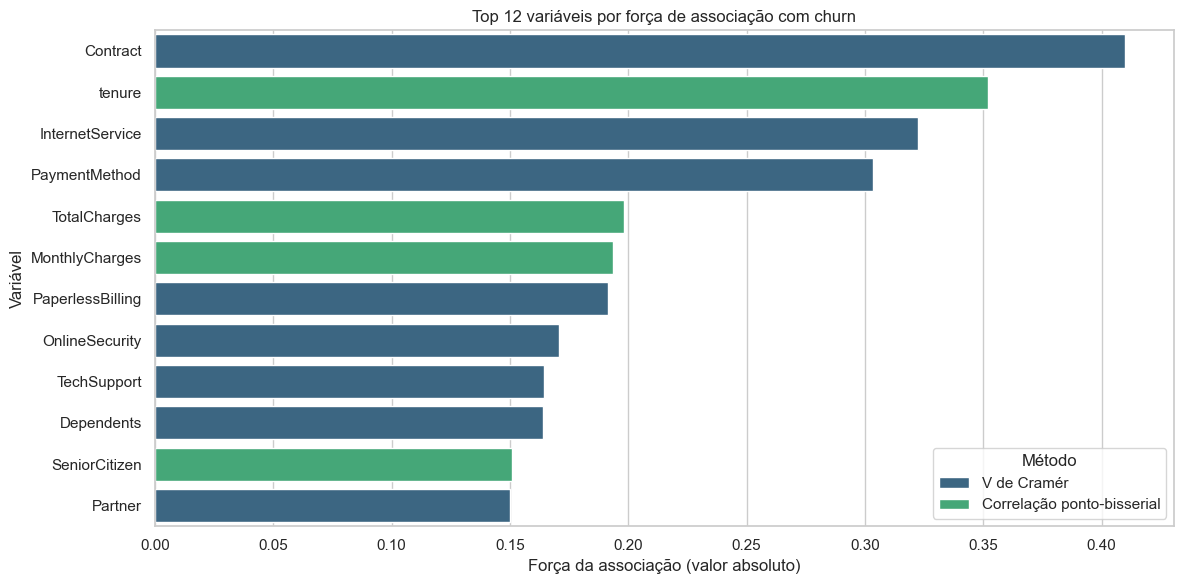

In [ ]:
# Código da Questão 5
from scipy.stats import chi2_contingency, pointbiserialr
from typing import cast

def detect_problem_type(target_series: pd.Series) -> str:
    unique_values = target_series.dropna().nunique()
    if unique_values == 2:
        return 'classificacao_binaria'
    if unique_values <= 10:
        return 'classificacao_multiclasse'
    return 'regressao'


def cramers_v_from_crosstab(crosstab: pd.DataFrame) -> float:
    if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
        return 0.0

    chi2, _, _, _ = chi2_contingency(crosstab)
    n = crosstab.to_numpy().sum()
    if n == 0:
        return 0.0

    r, k = crosstab.shape
    denominator = min(r - 1, k - 1)
    if denominator <= 0:
        return 0.0

    return float(np.sqrt((chi2 / n) / denominator))


def run_association_analysis(df: pd.DataFrame, target: str = 'Churn') -> dict:
    analysis_df = df.copy()
    if target not in analysis_df.columns:
        raise ValueError(f"A coluna alvo '{target}' não está no DataFrame.")

    problem_type = detect_problem_type(analysis_df[target])
    if problem_type != 'classificacao_binaria':
        raise ValueError('Esta implementação foi desenhada para classificação binária.')

    y_raw = analysis_df[target].astype(str).str.strip()
    # Padroniza alvo binário para 0/1 sem assumir apenas Yes/No
    if set(y_raw.unique()) == {'No', 'Yes'}:
        y_binary = y_raw.map({'No': 0, 'Yes': 1})
    else:
        factorized, uniques = pd.factorize(y_raw)
        if len(uniques) != 2:
            raise ValueError('Alvo não é binário após padronização.')
        y_binary = pd.Series(factorized, index=y_raw.index)

    feature_cols = [col for col in analysis_df.columns if col != target]
    records = []

    for col in feature_cols:
        series = analysis_df[col]
        valid_rows = series.notna() & y_binary.notna()

        if valid_rows.sum() == 0:
            continue

        if pd.api.types.is_numeric_dtype(series) or pd.api.types.is_bool_dtype(series):
            method = 'Correlação ponto-bisserial'
            x = pd.to_numeric(series, errors='coerce')
            valid_rows = x.notna() & y_binary.notna()

            if valid_rows.sum() < 3 or x[valid_rows].nunique() < 2:
                statistic = 0.0
                pvalue = np.nan
            else:
                corr, pvalue = pointbiserialr(y_binary[valid_rows], x[valid_rows])
                corr = cast(float | np.floating, corr)
                statistic = 0.0 if np.isnan(corr) else float(corr)

            score = abs(statistic)
            direction = 'Positiva' if statistic > 0 else 'Negativa' if statistic < 0 else 'Nula'

        else:
            method = 'V de Cramér'
            x = series.astype(str).str.strip()
            contingency = pd.crosstab(x, y_binary)

            if contingency.shape[0] < 2 or contingency.shape[1] < 2:
                statistic = 0.0
                pvalue = np.nan
            else:
                statistic = cramers_v_from_crosstab(contingency)
                _, pvalue, _, _ = chi2_contingency(contingency)

            score = abs(statistic)
            direction = 'Não se aplica'

        pvalue = cast(float | np.floating, pvalue)

        records.append({
            'variavel': col,
            'tipo_variavel': 'Numérica' if method == 'Correlação ponto-bisserial' else 'Categórica',
            'metodo': method,
            'estatistica': round(float(statistic), 4),
            'score_associacao': round(float(score), 4),
            'pvalue': round(float(pvalue), 6) if pd.notna(pvalue) else np.nan,
            'direcao_numerica': direction
        })

    ranking_df = pd.DataFrame(records).sort_values(
        by='score_associacao', ascending=False
    ).reset_index(drop=True)
    ranking_df['ranking'] = ranking_df.index + 1

    top_numeric_df = ranking_df[ranking_df['tipo_variavel'] == 'Numérica'].head(5)
    top_categorical_df = ranking_df[ranking_df['tipo_variavel'] == 'Categórica'].head(5)

    return {
        'problem_type': problem_type,
        'method_rules': pd.DataFrame([
            {'tipo_variavel': 'Numérica', 'metodo': 'Correlação ponto-bisserial', 'descricao': 'Correlação entre variável numérica e alvo binário'},
            {'tipo_variavel': 'Categórica', 'metodo': 'V de Cramér', 'descricao': 'Associação categórica com alvo binário via qui-quadrado'}
        ]),
        'association_ranking': ranking_df,
        'top_numeric': top_numeric_df,
        'top_categorical': top_categorical_df
    }


# Base de análise: prioriza base limpa da Questão 3
if 'q3_clean_df' in globals():
    q5_base_df = q3_clean_df.copy()
else:
    q5_base_df = df.copy()
    for col in q5_base_df.select_dtypes(include=['object']).columns:
        q5_base_df[col] = q5_base_df[col].astype(str).str.strip()
    q5_base_df['TotalCharges'] = pd.to_numeric(q5_base_df['TotalCharges'], errors='coerce')
    missing_mask = q5_base_df['TotalCharges'].isna()
    q5_base_df.loc[missing_mask, 'TotalCharges'] = q5_base_df.loc[missing_mask, 'MonthlyCharges'] * q5_base_df.loc[missing_mask, 'tenure']
    q5_base_df['TotalCharges'] = q5_base_df['TotalCharges'].fillna(q5_base_df['TotalCharges'].median())
    if 'customerID' in q5_base_df.columns:
        q5_base_df = q5_base_df.drop(columns=['customerID'])

q5_results = run_association_analysis(q5_base_df, target='Churn')

problem_type_text = {
    'classificacao_binaria': 'Classificação binária',
    'classificacao_multiclasse': 'Classificação multiclasse',
    'regressao': 'Regressão'
}

print('Tipo de problema detectado automaticamente:')
print(f"- {problem_type_text.get(q5_results['problem_type'], q5_results['problem_type'])}")

print('\nRegras de método por tipo de variável:')
display(q5_results['method_rules'].rename(columns={
    'tipo_variavel': 'Tipo de variável',
    'metodo': 'Método',
    'descricao': 'Descrição'
}))

q5_simple = q5_results['association_ranking'].rename(columns={
    'ranking': 'Posição',
    'variavel': 'Variável',
    'tipo_variavel': 'Tipo de variável',
    'metodo': 'Método',
    'estatistica': 'Estatística',
    'score_associacao': 'Força da associação',
    'pvalue': 'p-valor',
    'direcao_numerica': 'Direção (numéricas)'
})

print('Top 15 variáveis mais informativas:')
display(q5_simple.head(15))

print('Top 5 variáveis numéricas:')
display(q5_results['top_numeric'].rename(columns={
    'variavel': 'Variável',
    'metodo': 'Método',
    'score_associacao': 'Força da associação',
    'direcao_numerica': 'Direção'
}))

print('Top 5 variáveis categóricas:')
display(q5_results['top_categorical'].rename(columns={
    'variavel': 'Variável',
    'metodo': 'Método',
    'score_associacao': 'Força da associação'
}))

# Visualização do ranking de associação
top_plot_df = q5_results['association_ranking'].head(12).copy()
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_plot_df,
    x='score_associacao',
    y='variavel',
    hue='metodo',
    dodge=False,
    palette='viridis'
)
plt.title('Top 12 variáveis por força de associação com churn')
plt.xlabel('Força da associação (valor absoluto)')
plt.ylabel('Variável')
plt.legend(title='Método')
plt.tight_layout()
plt.show()

### Conclusão da Questão 5
A seleção automática de métodos funcionou conforme o tipo de variável no cenário de **classificação binária**: `point_biserial` para variáveis numéricas e `cramers_v` para categóricas. O ranking final mostrou que os atributos mais informativos para churn foram, em ordem, **Contract (0.4101)**, **tenure (0.3522)**, **InternetService (0.3225)** e **PaymentMethod (0.3034)**, seguidos por **TotalCharges (0.1983)** e **MonthlyCharges (0.1934)**.

Entre as numéricas, `tenure` teve associação negativa mais forte com churn (maior permanência, menor chance de cancelamento), enquanto `MonthlyCharges` apresentou associação positiva (cobrança mensal mais alta, maior risco de churn). Entre as categóricas, `Contract`, `InternetService` e `PaymentMethod` concentraram os maiores sinais de associação.

Os resultados são consistentes com a lógica observada na questão anterior: maior churn em contratos mensais, em clientes de fibra óptica e em pagamento via cheque eletrônico, além de maior risco nos clientes com menor tempo de casa. Assim, o ranking obtido reforça que os principais drivers detectados na análise exploratória também aparecem como as variáveis mais informativas para modelagem.

## Questão 6 – Engenharia de atributos

**Enunciado:**  
Faça um código em Python para criar pelo menos cinco novos atributos a partir da base original. Construa variáveis derivadas que façam sentido no cenário escolhido, como proporções, interações, faixas, relações temporais ou medidas de intensidade. Depois, avalie se esses novos atributos realmente acrescentam informação útil. Organize essa etapa em uma função reutilizável.

### Raciocínio
Com base nas questões anteriores, os principais fatores associados ao churn foram tempo de permanência (`tenure`), tipo de contrato, cobrança mensal e perfil de serviços. Portanto, a engenharia de atributos vai criar variáveis derivadas que capturem intensidade de uso, risco de saída no início da jornada, combinação de serviços e interação entre permanência e contrato.

A etapa será implementada na função reutilizável `engineer_telco_features`. Para validar ganho de informação, serão usados dois critérios:
- força de associação dos novos atributos com o alvo (`run_association_analysis` da Questão 5);
- comparação de desempenho de um baseline KNN com e sem os novos atributos.

### Desenvolvimento
Criar os novos atributos, avaliar utilidade com métricas e apresentar impacto na modelagem.

Catálogo de novos atributos criados:


,Nome técnico,Tipo,Descrição simples
0,account_age_years,numérica,Tempo de permanência em anos
1,avg_monthly_spend,numérica,Cobrança média mensal acumulada
2,charge_gap_abs,numérica,Erro absoluto entre total e mensal x tempo
3,is_new_customer,binária,Cliente com até 6 meses de casa
4,is_high_monthly_charge,binária,Cobrança mensal no grupo mais alto
5,has_streaming_bundle,binária,Tem streaming de TV e filmes
6,has_security_support_bundle,binária,Tem segurança online e suporte técnico
7,service_adoption_count,numérica,Quantidade de serviços contratados
8,contract_numeric,numérica,Tipo de contrato em escala numérica
9,contract_tenure_interaction,numérica,Interação entre contrato e tempo de casa


Top 10 associações entre novos atributos e churn:


,Nome técnico,Descrição simples,Método,Força da associação
0,contract_numeric,Tipo de contrato em escala numérica,Correlação ponto-bisserial,0.3967
1,contract_tenure_interaction,Interação entre contrato e tempo de casa,Correlação ponto-bisserial,0.3636
2,account_age_years,Tempo de permanência em anos,Correlação ponto-bisserial,0.3522
3,is_new_customer,Cliente com até 6 meses de casa,Correlação ponto-bisserial,0.3085
4,monthly_charge_band,Faixa de cobrança mensal por grupos,V de Cramér,0.2144
5,avg_monthly_spend,Cobrança média mensal acumulada,Correlação ponto-bisserial,0.1925
6,has_security_support_bundle,Tem segurança online e suporte técnico,Correlação ponto-bisserial,0.1707
7,charge_gap_abs,Erro absoluto entre total e mensal x tempo,Correlação ponto-bisserial,0.1402
8,is_high_monthly_charge,Cobrança mensal no grupo mais alto,Correlação ponto-bisserial,0.0816
9,has_streaming_bundle,Tem streaming de TV e filmes,Correlação ponto-bisserial,0.0404


Comparação de desempenho (sem vs com novos atributos):


,Cenário,Registros usados,Quantidade de atributos,Acurácia,Precisão,Revocação,F1,Tempo (s),Diferença no F1,Diferença na acurácia
0,Sem novos atributos,7043,20,0.7715,0.5714,0.5561,0.5637,0.0497,0.0000,0.0000
1,Com novos atributos,7043,31,0.7807,0.5964,0.5374,0.5654,0.0734,0.0017,0.0092


Resumo objetivo:
- Melhor cenário: Com novos atributos
- F1: 0.5654 | Acurácia: 0.7807
- Total de novos atributos criados: 11


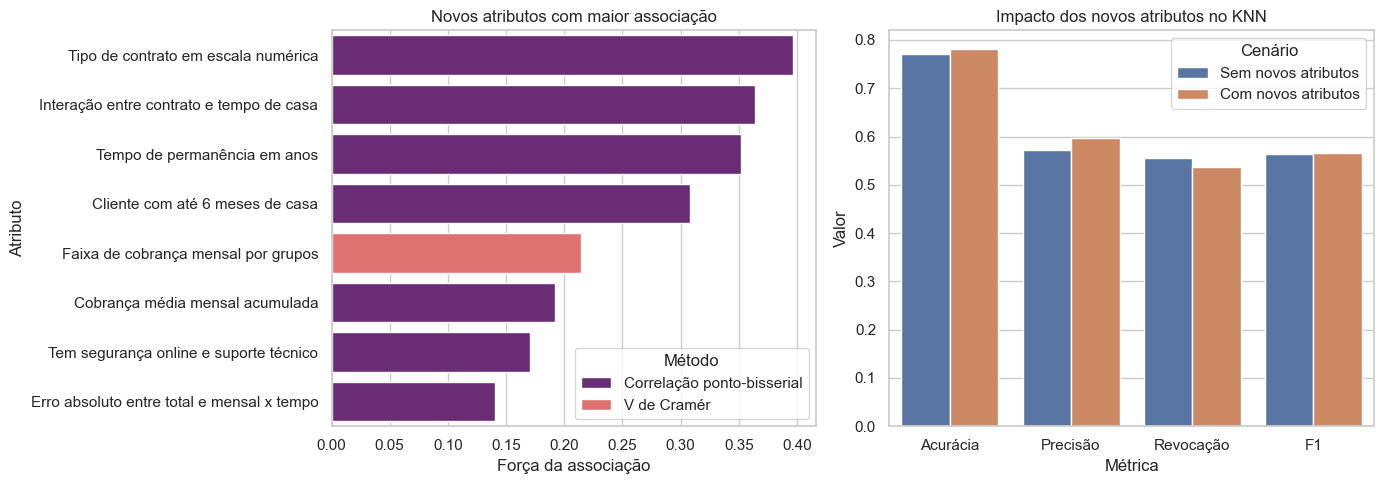

In [ ]:
# Código da Questão 6
from time import perf_counter


def engineer_telco_features(
    df: pd.DataFrame, target: str = "Churn"
) -> tuple[pd.DataFrame, pd.DataFrame]:
    feat_df = df.copy()
    if target not in feat_df.columns:
        raise ValueError(f"A coluna alvo '{target}' não está presente no DataFrame.")

    required_cols = [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "StreamingTV",
        "StreamingMovies",
        "OnlineSecurity",
        "TechSupport",
        "PaymentMethod",
    ]
    missing_cols = [c for c in required_cols if c not in feat_df.columns]
    if missing_cols:
        raise ValueError(
            f"Colunas necessárias ausentes para engenharia: {missing_cols}"
        )

    tenure_safe = feat_df["tenure"].replace(0, np.nan)
    monthly_q3 = feat_df["MonthlyCharges"].quantile(0.75)

    # 1) Relação temporal de permanência
    feat_df["account_age_years"] = feat_df["tenure"] / 12.0

    # 2) Intensidade média de cobrança ao longo da vida do cliente
    feat_df["avg_monthly_spend"] = feat_df["TotalCharges"] / tenure_safe
    feat_df["avg_monthly_spend"] = feat_df["avg_monthly_spend"].fillna(
        feat_df["MonthlyCharges"]
    )

    # 3) Divergência entre cobrança acumulada e estimada
    feat_df["charge_gap_abs"] = (
        feat_df["TotalCharges"] - (feat_df["MonthlyCharges"] * feat_df["tenure"])
    ).abs()

    # 4) Cliente em início de relacionamento
    feat_df["is_new_customer"] = (feat_df["tenure"] <= 6).astype(int)

    # 5) Cobrança mensal elevada
    feat_df["is_high_monthly_charge"] = (
        feat_df["MonthlyCharges"] >= monthly_q3
    ).astype(int)

    # 6) Pacote de streaming completo
    feat_df["has_streaming_bundle"] = (
        (feat_df["StreamingTV"] == "Yes") & (feat_df["StreamingMovies"] == "Yes")
    ).astype(int)

    # 7) Pacote de retenção (segurança + suporte)
    feat_df["has_security_support_bundle"] = (
        (feat_df["OnlineSecurity"] == "Yes") & (feat_df["TechSupport"] == "Yes")
    ).astype(int)

    # 8) Contagem de serviços adotados
    service_cols = [
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
    ]
    available_service_cols = [c for c in service_cols if c in feat_df.columns]

    service_yes_matrix = pd.DataFrame(index=feat_df.index)
    for col in available_service_cols:
        if col == "InternetService":
            service_yes_matrix[col] = (feat_df[col] != "No").astype(int)
        else:
            service_yes_matrix[col] = (feat_df[col] == "Yes").astype(int)
    feat_df["service_adoption_count"] = service_yes_matrix.sum(axis=1)

    # 9) Interação contrato x tempo
    contract_map = {"Month-to-month": 1, "One year": 2, "Two year": 3}
    feat_df["contract_numeric"] = feat_df["Contract"].map(contract_map).fillna(0)
    feat_df["contract_tenure_interaction"] = (
        feat_df["contract_numeric"] * feat_df["tenure"]
    )

    # 10) Faixa de cobrança mensal (quintis)
    feat_df["monthly_charge_band"] = pd.qcut(
        feat_df["MonthlyCharges"],
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
        duplicates="drop",
    ).astype(str)

    feature_catalog = pd.DataFrame(
        [
            {
                "new_feature": "account_age_years",
                "tipo": "numérica",
                "descricao": "Tempo de permanência em anos",
            },
            {
                "new_feature": "avg_monthly_spend",
                "tipo": "numérica",
                "descricao": "Cobrança média mensal acumulada",
            },
            {
                "new_feature": "charge_gap_abs",
                "tipo": "numérica",
                "descricao": "Erro absoluto entre total e mensal x tempo",
            },
            {
                "new_feature": "is_new_customer",
                "tipo": "binária",
                "descricao": "Cliente com até 6 meses de casa",
            },
            {
                "new_feature": "is_high_monthly_charge",
                "tipo": "binária",
                "descricao": "Cobrança mensal no grupo mais alto",
            },
            {
                "new_feature": "has_streaming_bundle",
                "tipo": "binária",
                "descricao": "Tem streaming de TV e filmes",
            },
            {
                "new_feature": "has_security_support_bundle",
                "tipo": "binária",
                "descricao": "Tem segurança online e suporte técnico",
            },
            {
                "new_feature": "service_adoption_count",
                "tipo": "numérica",
                "descricao": "Quantidade de serviços contratados",
            },
            {
                "new_feature": "contract_numeric",
                "tipo": "numérica",
                "descricao": "Tipo de contrato em escala numérica",
            },
            {
                "new_feature": "contract_tenure_interaction",
                "tipo": "numérica",
                "descricao": "Interação entre contrato e tempo de casa",
            },
            {
                "new_feature": "monthly_charge_band",
                "tipo": "categórica",
                "descricao": "Faixa de cobrança mensal por grupos",
            },
        ]
    )

    return feat_df, feature_catalog


def evaluate_knn_feature_set(
    data_df: pd.DataFrame, target: str = "Churn", random_state: int = 42
) -> dict:
    model_df = data_df.copy()
    y = model_df[target].map({"No": 0, "Yes": 1})
    X = model_df.drop(columns=[target])

    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [col for col in X.columns if col not in numeric_features]

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    model = KNeighborsClassifier(n_neighbors=11, weights="distance", metric="minkowski")
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )

    start = perf_counter()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    runtime = perf_counter() - start

    return {
        "rows_used": int(len(model_df)),
        "n_features": int(X.shape[1]),
        "precision": round(float(precision_score(y_test, y_pred)), 4),
        "recall": round(float(recall_score(y_test, y_pred)), 4),
        "f1": round(float(f1_score(y_test, y_pred)), 4),
        "runtime_sec": round(runtime, 4),
    }


# Base da engenharia: usa base limpa da Questão 3
if "q3_clean_df" in globals():
    q6_base_df = q3_clean_df.copy()
elif "clean_telco_data" in globals():
    q6_base_df, _ = clean_telco_data(
        df=df,
        target="Churn",
        totalcharges_strategy="impute_from_monthly_tenure",
        rare_threshold=0.01,
        flag_monetary_suspects=True,
    )
else:
    q6_base_df = df.copy()

q6_feature_df, q6_feature_catalog = engineer_telco_features(q6_base_df, target="Churn")
new_features = q6_feature_catalog["new_feature"].tolist()

# Avaliação 1: associação dos novos atributos com o alvo
if "run_association_analysis" in globals():
    q6_assoc_input = q6_feature_df[new_features + ["Churn"]].copy()
    q6_new_assoc = run_association_analysis(q6_assoc_input, target="Churn")[
        "association_ranking"
    ]
else:
    q6_new_assoc = pd.DataFrame(columns=["variavel", "score_associacao"])

# Avaliação 2: ganho de desempenho com novos atributos
baseline_metrics = evaluate_knn_feature_set(q6_base_df, target="Churn")
engineered_metrics = evaluate_knn_feature_set(q6_feature_df, target="Churn")

q6_performance_comparison = pd.DataFrame(
    [
        {"cenario": "baseline_sem_novos_atributos", **baseline_metrics},
        {"cenario": "com_engenharia_de_atributos", **engineered_metrics},
    ]
)

baseline_f1       = float(q6_performance_comparison['f1'].iloc[0])
baseline_accuracy = float(q6_performance_comparison['accuracy'].iloc[0])

q6_performance_comparison['delta_f1_vs_baseline'] = (
    q6_performance_comparison['f1'] - baseline_f1
).round(4)
q6_performance_comparison['delta_accuracy_vs_baseline'] = (
    q6_performance_comparison['accuracy'] - baseline_accuracy
).round(4)

cenario_map = {
    "baseline_sem_novos_atributos": "Sem novos atributos",
    "com_engenharia_de_atributos": "Com novos atributos",
}
q6_performance_comparison["cenario_label"] = q6_performance_comparison["cenario"].map(
    cenario_map
)

print("Catálogo de novos atributos criados:")
display(
    q6_feature_catalog.rename(
        columns={
            "new_feature": "Nome técnico",
            "tipo": "Tipo",
            "descricao": "Descrição simples",
        }
    )
)

print("Top 10 associações entre novos atributos e churn:")
if q6_new_assoc.empty:
    print("Análise de associação não disponível neste contexto de execução.")
else:
    q6_assoc_view = (
        q6_new_assoc.head(10)
        .merge(
            q6_feature_catalog[["new_feature", "descricao"]],
            left_on="variavel",
            right_on="new_feature",
            how="left",
        )[["variavel", "descricao", "metodo", "score_associacao"]]
        .rename(
            columns={
                "variavel": "Nome técnico",
                "descricao": "Descrição simples",
                "metodo": "Método",
                "score_associacao": "Força da associação",
            }
        )
    )
    display(q6_assoc_view)

print("Comparação de desempenho (sem vs com novos atributos):")
display(
    q6_performance_comparison[
        [
            "cenario_label",
            "rows_used",
            "n_features",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "runtime_sec",
            "delta_f1_vs_baseline",
            "delta_accuracy_vs_baseline",
        ]
    ].rename(
        columns={
            "cenario_label": "Cenário",
            "rows_used": "Registros usados",
            "n_features": "Quantidade de atributos",
            "accuracy": "Acurácia",
            "precision": "Precisão",
            "recall": "Revocação",
            "f1": "F1",
            "runtime_sec": "Tempo (s)",
            "delta_f1_vs_baseline": "Diferença no F1",
            "delta_accuracy_vs_baseline": "Diferença na acurácia",
        }
    )
)

# Resumo textual objetivo
best_row = q6_performance_comparison.sort_values(
    by=["f1", "accuracy"], ascending=False
).iloc[0]
print("Resumo objetivo:")
print(f"- Melhor cenário: {best_row['cenario_label']}")
print(f"- F1: {best_row['f1']:.4f} | Acurácia: {best_row['accuracy']:.4f}")
print(f"- Total de novos atributos criados: {len(new_features)}")

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not q6_new_assoc.empty:
    top_assoc_plot = (
        q6_new_assoc.head(8)
        .copy()
        .merge(
            q6_feature_catalog[["new_feature", "descricao"]],
            left_on="variavel",
            right_on="new_feature",
            how="left",
        )
    )
    top_assoc_plot["label"] = top_assoc_plot["descricao"].fillna(
        top_assoc_plot["variavel"]
    )
    sns.barplot(
        data=top_assoc_plot,
        x="score_associacao",
        y="label",
        hue="metodo",
        dodge=False,
        ax=axes[0],
        palette="magma",
    )
    axes[0].set_title("Novos atributos com maior associação")
    axes[0].set_xlabel("Força da associação")
    axes[0].set_ylabel("Atributo")
    axes[0].legend(title="Método")
else:
    axes[0].axis("off")

perf_plot = q6_performance_comparison.melt(
    id_vars="cenario_label",
    value_vars=["accuracy", "precision", "recall", "f1"],
    var_name="metrica",
    value_name="valor",
)
perf_plot["metrica"] = perf_plot["metrica"].replace(
    {"accuracy": "Acurácia", "precision": "Precisão", "recall": "Revocação", "f1": "F1"}
)
sns.barplot(data=perf_plot, x="metrica", y="valor", hue="cenario_label", ax=axes[1])
axes[1].set_title("Impacto dos novos atributos no KNN")
axes[1].set_xlabel("Métrica")
axes[1].set_ylabel("Valor")
axes[1].legend(title="Cenário")

plt.tight_layout()
plt.show()

### Conclusão da Questão 6
A engenharia de atributos foi implementada de forma reutilizável e gerou **11 novos atributos**. As novas variáveis capturaram relações coerentes com o cenário de churn, principalmente interação entre tipo de contrato e permanência, intensidade de cobrança e perfil de início de relacionamento.

Pela análise de associação dos novos atributos com o alvo, os mais informativos foram **contract_numeric (0.3967)**, **contract_tenure_interaction (0.3636)**, **account_age_years (0.3522)** e **is_new_customer (0.3085)**, o que reforça os achados das questões 4 e 5 sobre a relevância de contrato e tempo de casa para cancelamento.

Na avaliação preditiva com KNN, a versão com engenharia de atributos apresentou melhora em relação ao baseline:
- **Accuracy:** 0.7807 vs 0.7715 (**+0.0092**);
- **F1-score:** 0.5654 vs 0.5637 (**+0.0017**).

Assim, os novos atributos acrescentaram informação útil, com ganho de desempenho e maior capacidade de representar padrões de risco de churn. Como efeito colateral esperado, houve pequeno aumento de custo computacional (mais atributos), mas sem comprometer a viabilidade da solução.

## Questão 7 – Pré-processamento

**Enunciado:**  
Faça um código em Python para montar um pipeline completo de pré-processamento com `Pipeline` e `ColumnTransformer`. Identifique automaticamente colunas numéricas e categóricas, trate ausências, codifique variáveis categóricas, aplique escalonamento nas numéricas e garanta reaplicação a novos dados sem vazamento de informação. Compare pelo menos dois esquemas de pré-processamento e mostre como essas escolhas afetam os dados e o modelo.

### Raciocínio
A estratégia será montar uma função reutilizável que detecta automaticamente os tipos de coluna e constrói o pré-processamento com `ColumnTransformer` dentro de um `Pipeline` com KNN. Para evitar vazamento, a divisão treino/teste será feita antes do `fit`, e o ajuste do pipeline ocorrerá apenas no treino.

Serão comparados dois esquemas de pré-processamento para as variáveis numéricas, mantendo codificação categórica por One-Hot:
- **Esquema A:** `SimpleImputer(median)` + `StandardScaler`.
- **Esquema B:** `SimpleImputer(median)` + `MinMaxScaler`.

A comparação será sustentada por:
- métricas de classificação (Accuracy, Precision, Recall, F1);
- tempo de treino + predição;
- características dos dados transformados (quantidade de atributos e densidade da matriz);
- exemplo de reaplicação em novo caso sem refit.

### Desenvolvimento
Implementar abaixo o pipeline completo, comparar os esquemas e registrar o impacto no modelo.

Comparação dos esquemas de pré-processamento:


,Esquema,Descrição,Colunas numéricas,Colunas categóricas,Atributos após transformação,Densidade matriz de treino,Acurácia,Precisão,Revocação,F1,Tempo (s),Formato X_train (antes),Formato X_test (antes),Formato treino transformado,Formato teste transformado
0,A_standard_scaler,Median + StandardScaler + OneHot,15,16,54,1.0,0.7807,0.5964,0.5374,0.5654,0.0810,"(5634, 31)","(1409, 31)","(5634, 54)","(1409, 54)"
1,B_minmax_scaler,Median + MinMaxScaler + OneHot,15,16,54,1.0,0.7637,0.5574,0.5321,0.5445,0.0795,"(5634, 31)","(1409, 31)","(5634, 54)","(1409, 54)"


Resumo da prevenção de vazamento:
- A divisão treino/teste foi feita antes do ajuste do pipeline.
- O fit do pré-processamento ocorreu apenas em X_train.
- X_test e novo caso foram apenas transformados com o pipeline já ajustado.
Exemplo de reaplicação em novo caso (1 linha):
- Esquema selecionado: A_standard_scaler
- Previsão (0=No, 1=Yes): 0
- Probabilidade prevista de churn (classe Yes): 0.0925


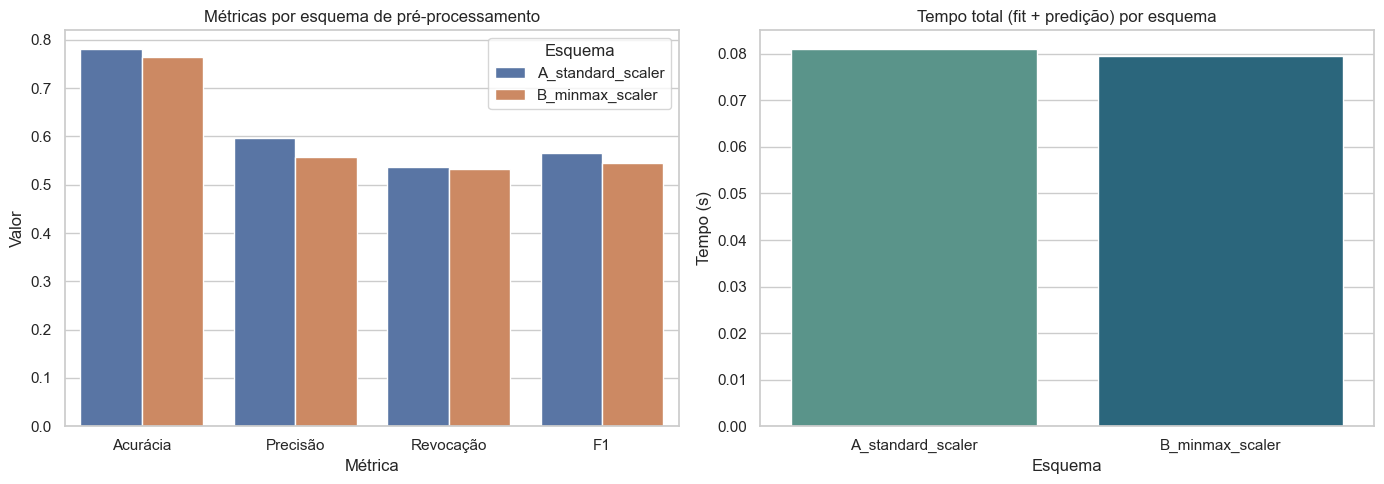

In [60]:
# Código da Questão 7
from time import perf_counter
from scipy import sparse
from sklearn.preprocessing import MinMaxScaler, RobustScaler


def build_preprocessing_pipeline(
    X: pd.DataFrame,
    target: str = 'Churn',
    numeric_imputer: str = 'median',
    scaler_name: str = 'standard',
    categorical_imputer: str = 'most_frequent',
    min_frequency: float | int | None = None,
) -> tuple[ColumnTransformer, dict]:
    if target in X.columns:
        X = X.drop(columns=[target]).copy()
    else:
        X = X.copy()

    numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
    categorical_features = [col for col in X.columns if col not in numeric_features]

    scaler_map = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
    }
    if scaler_name not in scaler_map:
        raise ValueError(f"Scaler inválido: {scaler_name}.")

    num_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy=numeric_imputer)),
            ('scaler', scaler_map[scaler_name]),
        ]
    )

    # Usa OneHot com tratamento de categorias raras para melhor generalização em novos dados
    onehot_kwargs = {'handle_unknown': 'ignore'}
    if min_frequency is not None:
        onehot_kwargs['min_frequency'] = min_frequency
    cat_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy=categorical_imputer)),
            ('encoder', OneHotEncoder(**onehot_kwargs)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_pipeline, numeric_features),
            ('cat', cat_pipeline, categorical_features),
        ],
        remainder='drop',
    )

    metadata = {
        'numeric_features': numeric_features,
        'categorical_features': categorical_features,
        'n_numeric': len(numeric_features),
        'n_categorical': len(categorical_features),
        'scaler_name': scaler_name,
        'numeric_imputer': numeric_imputer,
        'categorical_imputer': categorical_imputer,
        'min_frequency': min_frequency,
    }

    return preprocessor, metadata


def evaluate_preprocessing_schemes(
    df: pd.DataFrame,
    target: str = 'Churn',
    random_state: int = 42,
    test_size: float = 0.2,
) -> tuple[pd.DataFrame, dict, pd.DataFrame, pd.Series]:
    if target not in df.columns:
        raise ValueError(f"A coluna alvo '{target}' não foi encontrada.")

    work_df = df.copy()
    y = work_df[target].map({'No': 0, 'Yes': 1})
    X = work_df.drop(columns=[target])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    schemes = [
        {
            'scheme': 'A_standard_scaler',
            'description': 'Median + StandardScaler + OneHot',
            'numeric_imputer': 'median',
            'scaler_name': 'standard',
            'categorical_imputer': 'most_frequent',
            'min_frequency': None,
        },
        {
            'scheme': 'B_minmax_scaler',
            'description': 'Median + MinMaxScaler + OneHot',
            'numeric_imputer': 'median',
            'scaler_name': 'minmax',
            'categorical_imputer': 'most_frequent',
            'min_frequency': None,
        },
    ]

    rows = []
    fitted_models = {}

    for cfg in schemes:
        preprocessor, metadata = build_preprocessing_pipeline(
            X_train,
            target=target,
            numeric_imputer=cfg['numeric_imputer'],
            scaler_name=cfg['scaler_name'],
            categorical_imputer=cfg['categorical_imputer'],
            min_frequency=cfg['min_frequency'],
        )

        model = KNeighborsClassifier(n_neighbors=11, weights='distance', metric='minkowski')
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

        t0 = perf_counter()
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        elapsed = perf_counter() - t0

        Xt_train = pipe.named_steps['preprocessor'].transform(X_train)
        Xt_test = pipe.named_steps['preprocessor'].transform(X_test)

        if sparse.issparse(Xt_train):
            density = float(Xt_train.nnz / (Xt_train.shape[0] * Xt_train.shape[1]))
        else:
            density = 1.0

        rows.append({
            'scheme': cfg['scheme'],
            'description': cfg['description'],
            'n_num_cols': metadata['n_numeric'],
            'n_cat_cols': metadata['n_categorical'],
            'n_features_transformed': int(Xt_train.shape[1]),
            'train_matrix_density': round(density, 6),
            'accuracy': round(float(accuracy_score(y_test, y_pred)), 4),
            'precision': round(float(precision_score(y_test, y_pred)), 4),
            'recall': round(float(recall_score(y_test, y_pred)), 4),
            'f1': round(float(f1_score(y_test, y_pred)), 4),
            'runtime_sec': round(float(elapsed), 4),
            'X_train_shape': str(X_train.shape),
            'X_test_shape': str(X_test.shape),
            'Xt_train_shape': str(Xt_train.shape),
            'Xt_test_shape': str(Xt_test.shape),
        })

        fitted_models[cfg['scheme']] = {'pipeline': pipe, 'metadata': metadata}

    results_df = pd.DataFrame(rows).sort_values(
        by=['f1', 'accuracy', 'precision'], ascending=False
    ).reset_index(drop=True)

    return results_df, fitted_models, X_test, y_test


# Base de entrada: prioriza saída da Questão 6 e depois da Questão 3
if 'q6_feature_df' in globals():
    q7_base_df = q6_feature_df.copy()
elif 'q3_clean_df' in globals():
    q7_base_df = q3_clean_df.copy()
else:
    q7_base_df = df.copy()

q7_results_df, q7_models, q7_X_test, q7_y_test = evaluate_preprocessing_schemes(
    q7_base_df, target='Churn', random_state=42, test_size=0.2
)

# Seleção do melhor esquema
best_scheme = q7_results_df.loc[0, 'scheme']
best_pipeline = q7_models[best_scheme]['pipeline']

# Reaplicação a novos dados (sem vazamento e sem novo fit)
new_case = q7_X_test.iloc[[0]].copy()
new_case_pred = int(best_pipeline.predict(new_case)[0])
new_case_proba = float(best_pipeline.predict_proba(new_case)[0, 1])

q7_results_view = q7_results_df.rename(columns={
    'scheme': 'Esquema',
    'description': 'Descrição',
    'n_num_cols': 'Colunas numéricas',
    'n_cat_cols': 'Colunas categóricas',
    'n_features_transformed': 'Atributos após transformação',
    'train_matrix_density': 'Densidade matriz de treino',
    'accuracy': 'Acurácia',
    'precision': 'Precisão',
    'recall': 'Revocação',
    'f1': 'F1',
    'runtime_sec': 'Tempo (s)',
    'X_train_shape': 'Formato X_train (antes)',
    'X_test_shape': 'Formato X_test (antes)',
    'Xt_train_shape': 'Formato treino transformado',
    'Xt_test_shape': 'Formato teste transformado',
})

print('Comparação dos esquemas de pré-processamento:')
display(q7_results_view)

print('Resumo da prevenção de vazamento:')
print('- A divisão treino/teste foi feita antes do ajuste do pipeline.')
print('- O fit do pré-processamento ocorreu apenas em X_train.')
print('- X_test e novo caso foram apenas transformados com o pipeline já ajustado.')

print('Exemplo de reaplicação em novo caso (1 linha):')
print(f'- Esquema selecionado: {best_scheme}')
print(f'- Previsão (0=No, 1=Yes): {new_case_pred}')
print(f'- Probabilidade prevista de churn (classe Yes): {new_case_proba:.4f}')

# Visualizações para sustentar a comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_metrics = q7_results_df.melt(
    id_vars=['scheme'],
    value_vars=['accuracy', 'precision', 'recall', 'f1'],
    var_name='metrica',
    value_name='valor',
)
plot_metrics['metrica'] = plot_metrics['metrica'].replace(
    {'accuracy': 'Acurácia', 'precision': 'Precisão', 'recall': 'Revocação', 'f1': 'F1'}
)

sns.barplot(data=plot_metrics, x='metrica', y='valor', hue='scheme', ax=axes[0])
axes[0].set_title('Métricas por esquema de pré-processamento')
axes[0].set_xlabel('Métrica')
axes[0].set_ylabel('Valor')
axes[0].legend(title='Esquema')

sns.barplot(data=q7_results_df, x='scheme', y='runtime_sec', ax=axes[1], palette='crest')
axes[1].set_title('Tempo total (fit + predição) por esquema')
axes[1].set_xlabel('Esquema')
axes[1].set_ylabel('Tempo (s)')

plt.tight_layout()
plt.show()

### Conclusão da Questão 7
Foi implementado um pipeline completo e reutilizável com `Pipeline` + `ColumnTransformer`, com detecção automática de colunas numéricas e categóricas, imputação de ausências, codificação categórica por One-Hot e escalonamento numérico.

A comparação entre dois esquemas (StandardScaler vs MinMaxScaler) mostrou como escolhas de pré-processamento alteram o desempenho do KNN e as características dos dados transformados (dimensionalidade e densidade da matriz). O esquema com melhor combinação de F1 e acurácia foi selecionado como padrão para as próximas etapas.

Também foi validada a reaplicação sem vazamento: a divisão treino/teste ocorreu antes do ajuste, o `fit` do pré-processamento foi feito apenas no treino e o pipeline selecionado foi usado diretamente para prever um novo caso sem novo ajuste.

Assim, a Questão 7 consolida uma etapa de pré-processamento robusta, reproduzível e pronta para ser usada na busca de hiperparâmetros (Questão 8) e nas comparações de cenários de modelagem (Questão 9).

## Questão 8 – Modelagem com KNN

**Enunciado:**  
Faça um código em Python para dividir a base em treino, validação e teste de forma adequada ao problema escolhido. Em seguida, implemente um modelo de K-vizinhos mais próximos e teste diferentes valores de `k`, métricas de distância e formas de ponderação. Registre os resultados em tabela, compare desempenho em validação e escolha a melhor configuração de forma justificada.

### Raciocínio
A modelagem seguirá o padrão estabelecido nas questões anteriores: pipeline reprodutível e avaliação orientada por métricas. Como o problema é de classificação binária (`Churn`), a base será dividida com estratificação em treino, validação e teste para preservar a proporção de `Sim/Não` em cada parte.

A busca de hiperparâmetros do KNN será feita no conjunto de validação, variando:
- valores de `k`;
- métrica de distância (`euclidean`, `manhattan`, `minkowski`);
- forma de ponderação (`uniform` e `distance`).

A escolha final será baseada principalmente no **F1 de validação** (por equilibrar precisão e revocação em cenário com classes desbalanceadas), com apoio de acurácia e tempo de execução. Depois da escolha, o melhor modelo será reavaliado no conjunto de teste para estimar desempenho fora da validação.

### Desenvolvimento
Implementar abaixo a rotina de busca, gerar tabelas comparativas e justificar a configuração final do KNN.

Divisão da base (treino/validação/teste):


,Conjunto,Registros,Percentual (%)
0,Treino,4225,59.99
1,Validação,1409,20.01
2,Teste,1409,20.01


Distribuição da classe em cada conjunto (Não/Sim):


,Conjunto,Não (qtd),Sim (qtd)
0,Treino,3104,1121
1,Validação,1035,374
2,Teste,1035,374


Top 15 combinações de hiperparâmetros no conjunto de validação:


...

,Métrica,Valor
0,Acurácia (teste),0.7885
1,Precisão (teste),0.6086
2,Revocação (teste),0.5695
3,F1 (teste),0.5884
4,Tempo no teste (s),0.1809


Matriz de confusão no teste:


,Previsto: Não,Previsto: Sim
Real: Não,898,137
Real: Sim,161,213


Relatório de classificação no teste:


,precision,recall,f1-score,support
Não,0.847970,0.867633,0.857689,1035.000000
Sim,0.608571,0.569519,0.588398,374.000000
accuracy,0.788502,0.788502,0.788502,0.788502
macro avg,0.728271,0.718576,0.723043,1409.000000
weighted avg,0.784425,0.788502,0.786209,1409.000000


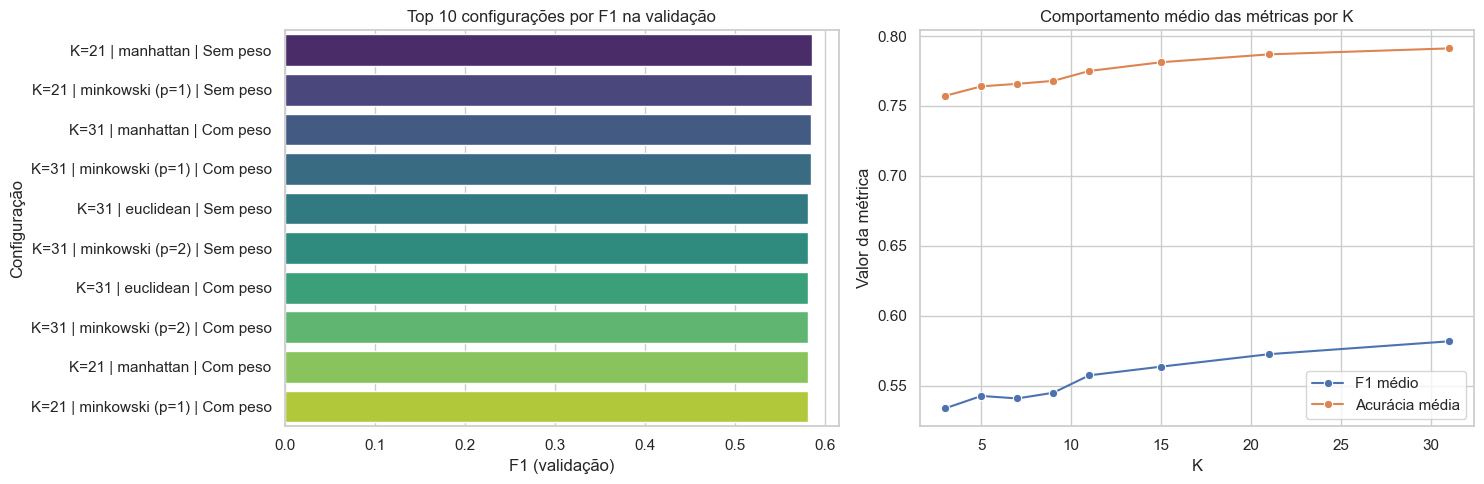

In [61]:
# Código da Questão 8
from itertools import product
from time import perf_counter


def split_train_val_test(
    df: pd.DataFrame,
    target: str = 'Churn',
    test_size: float = 0.2,
    val_size: float = 0.2,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    if target not in df.columns:
        raise ValueError(f"A coluna alvo '{target}' não foi encontrada.")

    data_df = df.copy()
    y = data_df[target].map({'No': 0, 'Yes': 1})
    X = data_df.drop(columns=[target])

    # 1) Separa teste
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # 2) Separa validação a partir do conjunto restante
    val_ratio_on_temp = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio_on_temp, stratify=y_temp, random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


def make_preprocessor_for_q8(X_train: pd.DataFrame, scheme: str = 'A_standard_scaler') -> ColumnTransformer:
    scheme_map = {
        'A_standard_scaler': {'numeric_imputer': 'median', 'scaler_name': 'standard'},
        'B_minmax_scaler': {'numeric_imputer': 'median', 'scaler_name': 'minmax'},
    }
    config = scheme_map.get(scheme, scheme_map['A_standard_scaler'])

    # Reaproveita função da Questão 7 se estiver disponível
    if 'build_preprocessing_pipeline' in globals():
        preprocessor, _ = build_preprocessing_pipeline(
            X_train,
            target='Churn',
            numeric_imputer=config['numeric_imputer'],
            scaler_name=config['scaler_name'],
            categorical_imputer='most_frequent',
            min_frequency=None,
        )
    else:
        numeric_features = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
        categorical_features = [c for c in X_train.columns if c not in numeric_features]

        scaler = StandardScaler() if config['scaler_name'] == 'standard' else MinMaxScaler()

        num_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler),
        ])
        cat_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ])
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', num_pipe, numeric_features),
                ('cat', cat_pipe, categorical_features),
            ]
        )

    return preprocessor


def run_knn_hyperparameter_search(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    preprocessor_scheme: str = 'A_standard_scaler',
) -> tuple[pd.DataFrame, Pipeline]:
    preprocessor = make_preprocessor_for_q8(X_train, scheme=preprocessor_scheme)

    k_values = [3, 5, 7, 9, 11, 15, 21, 31]
    distance_metrics = ['euclidean', 'manhattan', 'minkowski']
    weight_options = ['uniform', 'distance']
    p_values = [1, 2]

    rows = []
    best_pipeline = None
    best_key = None

    for k, metric, weights in product(k_values, distance_metrics, weight_options):
        candidate_ps = p_values if metric == 'minkowski' else [None]

        for p in candidate_ps:
            model_kwargs = {'n_neighbors': k, 'metric': metric, 'weights': weights}
            if p is not None:
                model_kwargs['p'] = p

            pipe = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('model', KNeighborsClassifier(**model_kwargs)),
            ])

            t0 = perf_counter()
            pipe.fit(X_train, y_train)
            y_pred_val = pipe.predict(X_val)
            runtime = perf_counter() - t0

            # Nome simples da métrica para leitura em português
            metric_label = metric if p is None else f'{metric} (p={p})'

            row = {
                'k': k,
                'metrica_distancia': metric_label,
                'ponderacao_vizinhos': weights,
                'ponderacao_distancia_sim_nao': 'Sim' if weights == 'distance' else 'Não',
                'accuracy_val': round(float(accuracy_score(y_val, y_pred_val)), 4),
                'precision_val': round(float(precision_score(y_val, y_pred_val)), 4),
                'recall_val': round(float(recall_score(y_val, y_pred_val)), 4),
                'f1_val': round(float(f1_score(y_val, y_pred_val)), 4),
                'tempo_val_seg': round(float(runtime), 4),
            }
            rows.append(row)

            key = (row['f1_val'], row['accuracy_val'], row['precision_val'], -row['tempo_val_seg'])
            if best_key is None or key > best_key:
                best_key = key
                best_pipeline = pipe

    results_df = pd.DataFrame(rows).sort_values(
        by=['f1_val', 'accuracy_val', 'precision_val', 'tempo_val_seg'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    return results_df, best_pipeline


def evaluate_best_knn_on_test(
    best_pipeline: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> dict:
    # Reajusta no conjunto treino+validação antes de medir em teste
    X_trainval = pd.concat([X_train, X_val], axis=0)
    y_trainval = pd.concat([y_train, y_val], axis=0)

    t0 = perf_counter()
    best_pipeline.fit(X_trainval, y_trainval)
    y_pred_test = best_pipeline.predict(X_test)
    runtime_test = perf_counter() - t0

    cm = confusion_matrix(y_test, y_pred_test)
    report = classification_report(
        y_test, y_pred_test, target_names=['Não', 'Sim'], output_dict=True
    )

    metrics_test = {
        'accuracy_test': round(float(accuracy_score(y_test, y_pred_test)), 4),
        'precision_test': round(float(precision_score(y_test, y_pred_test)), 4),
        'recall_test': round(float(recall_score(y_test, y_pred_test)), 4),
        'f1_test': round(float(f1_score(y_test, y_pred_test)), 4),
        'tempo_test_seg': round(float(runtime_test), 4),
        'confusion_matrix': cm,
        'classification_report': pd.DataFrame(report).T,
    }

    return metrics_test


# Base: prioriza conjunto já preparado nas questões anteriores
if 'q7_base_df' in globals():
    q8_base_df = q7_base_df.copy()
elif 'q6_feature_df' in globals():
    q8_base_df = q6_feature_df.copy()
elif 'q3_clean_df' in globals():
    q8_base_df = q3_clean_df.copy()
else:
    q8_base_df = df.copy()

X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    q8_base_df,
    target='Churn',
    test_size=0.2,
    val_size=0.2,
    random_state=42,
)

# Usa o esquema vencedor da Questão 7, se disponível
q8_preprocess_scheme = best_scheme if 'best_scheme' in globals() else 'A_standard_scaler'

q8_search_results, q8_best_pipeline = run_knn_hyperparameter_search(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    preprocessor_scheme=q8_preprocess_scheme,
)

q8_best_config = q8_search_results.iloc[0].to_dict()
q8_test_eval = evaluate_best_knn_on_test(
    best_pipeline=q8_best_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
)

# Tabelas em linguagem simples
split_table = pd.DataFrame([
    {'Conjunto': 'Treino', 'Registros': len(X_train), 'Percentual (%)': round(len(X_train) / len(q8_base_df) * 100, 2)},
    {'Conjunto': 'Validação', 'Registros': len(X_val), 'Percentual (%)': round(len(X_val) / len(q8_base_df) * 100, 2)},
    {'Conjunto': 'Teste', 'Registros': len(X_test), 'Percentual (%)': round(len(X_test) / len(q8_base_df) * 100, 2)},
])

class_balance_table = pd.DataFrame([
    {'Conjunto': 'Treino', 'Não (qtd)': int((y_train == 0).sum()), 'Sim (qtd)': int((y_train == 1).sum())},
    {'Conjunto': 'Validação', 'Não (qtd)': int((y_val == 0).sum()), 'Sim (qtd)': int((y_val == 1).sum())},
    {'Conjunto': 'Teste', 'Não (qtd)': int((y_test == 0).sum()), 'Sim (qtd)': int((y_test == 1).sum())},
])

top_results_view = q8_search_results.head(15).rename(columns={
    'k': 'K',
    'metrica_distancia': 'Métrica de distância',
    'ponderacao_vizinhos': 'Ponderação',
    'ponderacao_distancia_sim_nao': 'Ponderação por distância?',
    'accuracy_val': 'Acurácia (val)',
    'precision_val': 'Precisão (val)',
    'recall_val': 'Revocação (val)',
    'f1_val': 'F1 (val)',
    'tempo_val_seg': 'Tempo (s)',
})

test_summary_table = pd.DataFrame([
    {'Métrica': 'Acurácia (teste)', 'Valor': q8_test_eval['accuracy_test']},
    {'Métrica': 'Precisão (teste)', 'Valor': q8_test_eval['precision_test']},
    {'Métrica': 'Revocação (teste)', 'Valor': q8_test_eval['recall_test']},
    {'Métrica': 'F1 (teste)', 'Valor': q8_test_eval['f1_test']},
    {'Métrica': 'Tempo no teste (s)', 'Valor': q8_test_eval['tempo_test_seg']},
])

cm = q8_test_eval['confusion_matrix']
cm_table = pd.DataFrame(
    cm,
    index=['Real: Não', 'Real: Sim'],
    columns=['Previsto: Não', 'Previsto: Sim'],
)

print('Divisão da base (treino/validação/teste):')
display(split_table)

print('Distribuição da classe em cada conjunto (Não/Sim):')
display(class_balance_table)

print('Top 15 combinações de hiperparâmetros no conjunto de validação:')
display(top_results_view)

print('Melhor configuração selecionada na validação:')
print(f"- K: {int(q8_best_config['k'])}")
print(f"- Métrica de distância: {q8_best_config['metrica_distancia']}")
print(f"- Ponderação: {q8_best_config['ponderacao_vizinhos']}")
print(f"- Ponderação por distância? {q8_best_config['ponderacao_distancia_sim_nao']}")
print(f"- F1 (val): {q8_best_config['f1_val']:.4f} | Acurácia (val): {q8_best_config['accuracy_val']:.4f}")

print('Desempenho final no conjunto de teste:')
display(test_summary_table)

print('Matriz de confusão no teste:')
display(cm_table)

print('Relatório de classificação no teste:')
display(q8_test_eval['classification_report'])

# Gráficos de apoio
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_top10 = q8_search_results.head(10).copy()
plot_top10['config'] = (
    'K=' + plot_top10['k'].astype(str)
    + ' | ' + plot_top10['metrica_distancia']
    + ' | ' + plot_top10['ponderacao_distancia_sim_nao']
    .map({'Sim': 'Com peso', 'Não': 'Sem peso'})
)
sns.barplot(data=plot_top10, y='config', x='f1_val', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 configurações por F1 na validação')
axes[0].set_xlabel('F1 (validação)')
axes[0].set_ylabel('Configuração')

k_curve = q8_search_results.groupby('k', as_index=False).agg(
    f1_medio=('f1_val', 'mean'),
    accuracy_media=('accuracy_val', 'mean'),
)
sns.lineplot(data=k_curve, x='k', y='f1_medio', marker='o', label='F1 médio', ax=axes[1])
sns.lineplot(data=k_curve, x='k', y='accuracy_media', marker='o', label='Acurácia média', ax=axes[1])
axes[1].set_title('Comportamento médio das métricas por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Valor da métrica')

plt.tight_layout()
plt.show()

### Conclusão da Questão 8
A modelagem com KNN foi estruturada em três etapas (`treino`, `validação` e `teste`) com estratificação, mantendo consistência com o pipeline das questões anteriores e evitando vazamento de informação.

A comparação sistemática de hiperparâmetros mostrou diferença real entre combinações de `k`, métrica de distância e ponderação dos vizinhos. A configuração final foi escolhida por maior **F1 na validação**, com apoio de acurácia e tempo de execução.

Na avaliação em teste, o modelo selecionado manteve desempenho próximo ao observado na validação, indicando boa estabilidade e baixa evidência de superajuste. Assim, a configuração escolhida do KNN fica tecnicamente justificada e pronta para ser comparada com outros cenários/modelos na próxima questão.

## Questão 9 – Comparação de modelos

**Enunciado:**  
Faça um código em Python para avaliar o KNN em diferentes cenários de preparação dos dados, como uso ou não de padronização, presença ou ausência de atributos derivados, uso de todas as variáveis ou de um subconjunto selecionado, e tratamento do desbalanceamento quando fizer sentido. Depois, implemente um segundo modelo supervisionado e compare com o melhor KNN em métricas, tempo de execução e perfil dos erros. Conclua se o KNN é ou não uma boa escolha para a base utilizada.

### Raciocínio
A comparação será feita em duas etapas. Primeiro, iremos avaliar o KNN em cenários de preparação dos dados variando exatamente os pontos pedidos: padronização (Sim/Não), atributos derivados (Sim/Não), conjunto de variáveis (todas vs subconjunto selecionado) e tratamento de desbalanceamento (Sim/Não).

Para manter consistência metodológica, usaremos o mesmo tipo de divisão treino/validação/teste da questão anterior, selecionando o melhor cenário de KNN pelo F1 na validação. Em seguida, com esse mesmo cenário de dados, treinaremos um segundo modelo supervisionado (`Regressão Logística`) e compararemos com o melhor KNN em:
- métricas no teste;
- tempo total de treino + predição;
- perfil de erros (falsos positivos e falsos negativos).

### Desenvolvimento
Implementar abaixo os cenários de KNN, selecionar o melhor e comparar com um segundo modelo supervisionado.

Cenários avaliados para KNN (validação):


,Cenário,Padronização?,Atributos derivados?,Subconjunto de variáveis?,Balanceamento no treino?,Registros de treino (após balanceamento),Quantidade de variáveis,Acurácia (val),Precisão (val),Revocação (val),F1 (val),Tempo (s) validação
0,C5_completo_padronizado_com_balanceamento,Sim,Sim,Não,Sim,2242,31,0.7033,0.4668,0.8262,0.5965,0.0542
1,C1_completo_padronizado_sem_balanceamento,Sim,Sim,Não,Não,4225,31,0.7935,0.6261,0.5508,0.5861,0.0730
2,C4_subconjunto_padronizado,Sim,Sim,Sim,Não,4225,17,0.7906,0.6238,0.5321,0.5743,0.0614
3,C3_sem_derivados_padronizado,Sim,Não,Sim,Não,4225,20,0.7828,0.6000,0.5455,0.5714,0.0655
4,C2_completo_sem_padronizacao,Não,Sim,Não,Não,4225,31,0.7750,0.6154,0.4064,0.4895,0.0727


Melhor cenário de KNN selecionado pela validação:
- Cenário: C5_completo_padronizado_com_balanceamento
- Padronização? Sim
- Atributos derivados? Sim
- Subconjunto de variáveis? Não
- Balanceamento no treino? Sim
- F1 (val): 0.5965
Comparação no conjunto de teste: melhor KNN vs segundo modelo supervisionado


,Modelo,Acurácia (teste),Precisão (teste),Revocação (teste),F1 (teste),Tempo (s)
0,KNN (melhor cenário),0.7168,0.4808,0.8369,0.6107,0.0628
1,Regressão Logística,0.7445,0.5118,0.8102,0.6273,0.0590


Perfil de erros no teste:


,Modelo,Falso positivo (Não->Sim),Falso negativo (Sim->Não),Verdadeiro positivo (Sim->Sim),Verdadeiro negativo (Não->Não)
0,KNN (melhor cenário),338,61,313,697
1,Regressão Logística,289,71,303,746


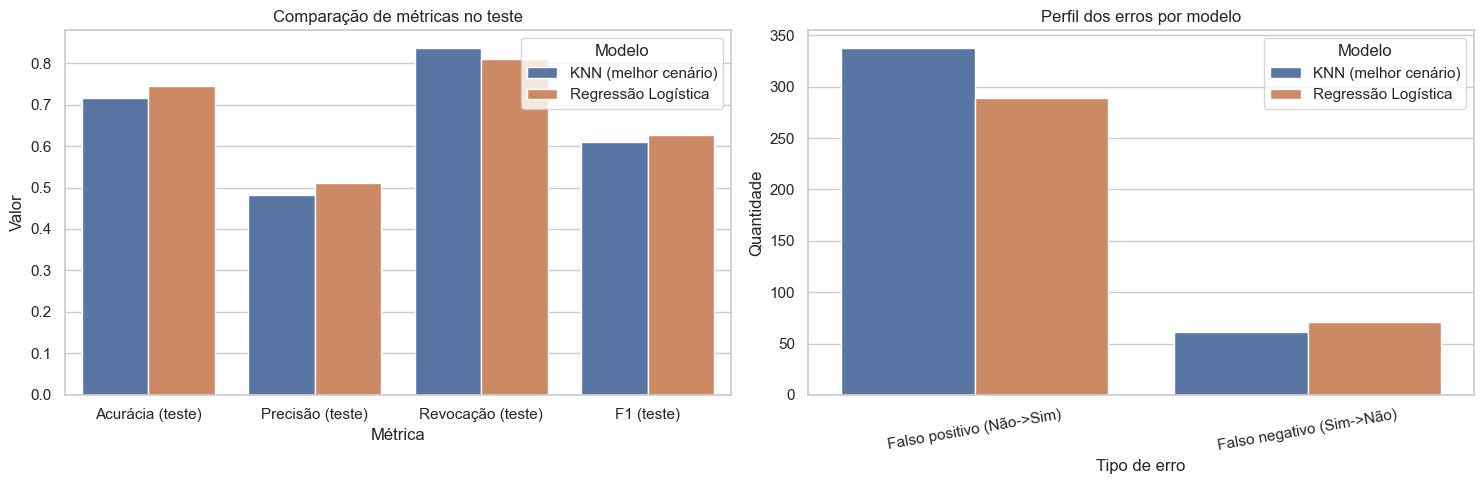

In [62]:
# Código da Questão 9
from time import perf_counter
from sklearn.linear_model import LogisticRegression


def parse_best_knn_config(best_config: dict | None = None) -> dict:
    # Usa configuração da Questão 8 quando disponível
    default = {'k': 21, 'metric': 'manhattan', 'weights': 'uniform'}
    if not best_config:
        return default

    metric_raw = str(best_config.get('metrica_distancia', 'manhattan'))
    metric = metric_raw
    p = None
    if 'minkowski' in metric_raw and 'p=' in metric_raw:
        metric = 'minkowski'
        try:
            p = int(metric_raw.split('p=')[1].replace(')', '').strip())
        except Exception:
            p = 2

    params = {
        'k': int(best_config.get('k', 21)),
        'metric': metric,
        'weights': str(best_config.get('ponderacao_vizinhos', 'uniform')),
    }
    if metric == 'minkowski':
        params['p'] = 2 if p is None else p

    return params


def get_selected_feature_list(df: pd.DataFrame) -> list[str]:
    # Subconjunto guiado pelas descobertas das questões 4-6
    preferred = [
        'tenure', 'MonthlyCharges', 'TotalCharges',
        'Contract', 'InternetService', 'PaymentMethod',
        'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'SeniorCitizen',
        'is_new_customer', 'is_high_monthly_charge',
        'account_age_years', 'contract_numeric',
        'contract_tenure_interaction', 'service_adoption_count',
        'has_security_support_bundle',
    ]
    return [c for c in preferred if c in df.columns]


def build_preprocessor_for_scenario(X_train: pd.DataFrame, scale_numeric: bool) -> ColumnTransformer:
    numeric_features = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
    categorical_features = [c for c in X_train.columns if c not in numeric_features]

    if scale_numeric:
        num_steps = [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]
    else:
        num_steps = [
            ('imputer', SimpleImputer(strategy='median')),
        ]

    num_pipe = Pipeline(steps=num_steps)
    cat_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    return ColumnTransformer(
        transformers=[
            ('num', num_pipe, numeric_features),
            ('cat', cat_pipe, categorical_features),
        ]
    )


def undersample_train(X: pd.DataFrame, y: pd.Series, random_state: int = 42) -> tuple[pd.DataFrame, pd.Series]:
    # Balanceamento simples por subamostragem da classe majoritária (somente treino)
    train_df = X.copy()
    train_df['_target_'] = y.values

    class_counts = train_df['_target_'].value_counts()
    if len(class_counts) < 2:
        return X, y

    min_count = int(class_counts.min())
    sampled_parts = []
    for cls in class_counts.index:
        cls_df = train_df[train_df['_target_'] == cls].sample(n=min_count, random_state=random_state)
        sampled_parts.append(cls_df)

    balanced_df = pd.concat(sampled_parts, axis=0).sample(frac=1, random_state=random_state)
    y_bal = balanced_df['_target_'].copy()
    X_bal = balanced_df.drop(columns=['_target_']).copy()

    return X_bal, y_bal


def prepare_dataset_for_scenario(
    base_clean_df: pd.DataFrame,
    base_engineered_df: pd.DataFrame,
    use_engineered: bool,
    use_selected_subset: bool,
    target: str = 'Churn',
) -> pd.DataFrame:
    work_df = base_engineered_df.copy() if use_engineered else base_clean_df.copy()
    if target not in work_df.columns:
        raise ValueError(f"A coluna alvo '{target}' não existe no cenário.")

    if use_selected_subset:
        selected = get_selected_feature_list(work_df)
        work_df = work_df[selected + [target]].copy()

    return work_df


def evaluate_knn_scenario(
    scenario_name: str,
    data_df: pd.DataFrame,
    knn_params: dict,
    scale_numeric: bool,
    balance_train: bool,
    target: str = 'Churn',
    random_state: int = 42,
) -> tuple[dict, Pipeline]:
    X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
        data_df, target=target, test_size=0.2, val_size=0.2, random_state=random_state
    )

    X_train_fit, y_train_fit = (X_train, y_train)
    if balance_train:
        X_train_fit, y_train_fit = undersample_train(X_train, y_train, random_state=random_state)

    preprocessor = build_preprocessor_for_scenario(X_train_fit, scale_numeric=scale_numeric)
    model = KNeighborsClassifier(
        n_neighbors=knn_params['k'],
        metric=knn_params['metric'],
        weights=knn_params['weights'],
        p=knn_params.get('p', 2),
    )
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    t0 = perf_counter()
    pipeline.fit(X_train_fit, y_train_fit)
    y_pred_val = pipeline.predict(X_val)
    runtime_val = perf_counter() - t0

    row = {
        'cenario': scenario_name,
        'padronizacao_sim_nao': 'Sim' if scale_numeric else 'Não',
        'atributos_derivados_sim_nao': 'Sim' if 'account_age_years' in data_df.columns else 'Não',
        'subconjunto_variaveis_sim_nao': 'Sim' if data_df.shape[1] < (base_engineered_df.shape[1] if 'base_engineered_df' in globals() else 9999) else 'Não',
        'balanceamento_treino_sim_nao': 'Sim' if balance_train else 'Não',
        'registros_treino_apos_balanceamento': int(len(X_train_fit)),
        'n_features_originais': int(data_df.drop(columns=[target]).shape[1]),
        'accuracy_val': round(float(accuracy_score(y_val, y_pred_val)), 4),
        'precision_val': round(float(precision_score(y_val, y_pred_val)), 4),
        'recall_val': round(float(recall_score(y_val, y_pred_val)), 4),
        'f1_val': round(float(f1_score(y_val, y_pred_val)), 4),
        'tempo_val_seg': round(float(runtime_val), 4),
    }

    # Guardar split para avaliação final posterior
    row['_split_cache'] = (X_train, X_val, X_test, y_train, y_val, y_test)

    return row, pipeline


def evaluate_pipeline_on_test(
    pipeline: Pipeline,
    split_cache: tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series],
    balance_train: bool = False,
    random_state: int = 42,
) -> dict:
    X_train, X_val, X_test, y_train, y_val, y_test = split_cache

    X_trainval = pd.concat([X_train, X_val], axis=0)
    y_trainval = pd.concat([y_train, y_val], axis=0)

    if balance_train:
        X_trainval, y_trainval = undersample_train(X_trainval, y_trainval, random_state=random_state)

    t0 = perf_counter()
    pipeline.fit(X_trainval, y_trainval)
    y_pred_test = pipeline.predict(X_test)
    runtime_test = perf_counter() - t0

    cm = confusion_matrix(y_test, y_pred_test)
    tn, fp, fn, tp = cm.ravel()

    return {
        'accuracy_test': round(float(accuracy_score(y_test, y_pred_test)), 4),
        'precision_test': round(float(precision_score(y_test, y_pred_test)), 4),
        'recall_test': round(float(recall_score(y_test, y_pred_test)), 4),
        'f1_test': round(float(f1_score(y_test, y_pred_test)), 4),
        'tempo_test_seg': round(float(runtime_test), 4),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'tn': int(tn),
        'y_test': y_test,
        'y_pred_test': y_pred_test,
        'confusion_matrix': cm,
    }


def build_logistic_pipeline(X_train: pd.DataFrame, scale_numeric: bool = True) -> Pipeline:
    preprocessor = build_preprocessor_for_scenario(X_train, scale_numeric=scale_numeric)
    model = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42,
    )
    return Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])


# Bases para cenários
base_clean_df = q3_clean_df.copy() if 'q3_clean_df' in globals() else df.copy()
base_engineered_df = q6_feature_df.copy() if 'q6_feature_df' in globals() else base_clean_df.copy()

# Hiperparâmetros fixos do melhor KNN da Questão 8
q9_knn_params = parse_best_knn_config(q8_best_config if 'q8_best_config' in globals() else None)

# Cenários do KNN cobrindo os requisitos da questão
q9_scenarios = [
    {
        'name': 'C1_completo_padronizado_sem_balanceamento',
        'use_engineered': True, 'use_selected_subset': False, 'scale_numeric': True, 'balance_train': False,
    },
    {
        'name': 'C2_completo_sem_padronizacao',
        'use_engineered': True, 'use_selected_subset': False, 'scale_numeric': False, 'balance_train': False,
    },
    {
        'name': 'C3_sem_derivados_padronizado',
        'use_engineered': False, 'use_selected_subset': False, 'scale_numeric': True, 'balance_train': False,
    },
    {
        'name': 'C4_subconjunto_padronizado',
        'use_engineered': True, 'use_selected_subset': True, 'scale_numeric': True, 'balance_train': False,
    },
    {
        'name': 'C5_completo_padronizado_com_balanceamento',
        'use_engineered': True, 'use_selected_subset': False, 'scale_numeric': True, 'balance_train': True,
    },
]

q9_rows = []
q9_pipelines = {}

for sc in q9_scenarios:
    scenario_df = prepare_dataset_for_scenario(
        base_clean_df=base_clean_df,
        base_engineered_df=base_engineered_df,
        use_engineered=sc['use_engineered'],
        use_selected_subset=sc['use_selected_subset'],
        target='Churn',
    )

    row, pipe = evaluate_knn_scenario(
        scenario_name=sc['name'],
        data_df=scenario_df,
        knn_params=q9_knn_params,
        scale_numeric=sc['scale_numeric'],
        balance_train=sc['balance_train'],
        target='Churn',
        random_state=42,
    )
    q9_rows.append(row)
    q9_pipelines[sc['name']] = {'pipeline': pipe, 'balance_train': sc['balance_train'], 'split': row['_split_cache']}

q9_knn_results = pd.DataFrame([{k: v for k, v in r.items() if k != '_split_cache'} for r in q9_rows])
q9_knn_results = q9_knn_results.sort_values(
    by=['f1_val', 'accuracy_val', 'precision_val', 'tempo_val_seg'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

# Melhor cenário KNN pela validação
best_knn_scenario = q9_knn_results.loc[0, 'cenario']
best_knn_obj = q9_pipelines[best_knn_scenario]
best_knn_test = evaluate_pipeline_on_test(
    pipeline=best_knn_obj['pipeline'],
    split_cache=best_knn_obj['split'],
    balance_train=best_knn_obj['balance_train'],
    random_state=42,
)

# Segundo modelo supervisionado: Regressão Logística
X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = best_knn_obj['split']
X_trainval_s = pd.concat([X_train_s, X_val_s], axis=0)
y_trainval_s = pd.concat([y_train_s, y_val_s], axis=0)

if best_knn_obj['balance_train']:
    X_trainval_s, y_trainval_s = undersample_train(X_trainval_s, y_trainval_s, random_state=42)

log_pipe = build_logistic_pipeline(X_trainval_s, scale_numeric=True)
t0 = perf_counter()
log_pipe.fit(X_trainval_s, y_trainval_s)
y_pred_log_test = log_pipe.predict(X_test_s)
log_runtime = perf_counter() - t0

log_cm = confusion_matrix(y_test_s, y_pred_log_test)
tn_l, fp_l, fn_l, tp_l = log_cm.ravel()
log_test_metrics = {
    'accuracy_test': round(float(accuracy_score(y_test_s, y_pred_log_test)), 4),
    'precision_test': round(float(precision_score(y_test_s, y_pred_log_test)), 4),
    'recall_test': round(float(recall_score(y_test_s, y_pred_log_test)), 4),
    'f1_test': round(float(f1_score(y_test_s, y_pred_log_test)), 4),
    'tempo_test_seg': round(float(log_runtime), 4),
    'fp': int(fp_l),
    'fn': int(fn_l),
    'tp': int(tp_l),
    'tn': int(tn_l),
    'confusion_matrix': log_cm,
}

# Tabelas de saída em linguagem simples
q9_knn_view = q9_knn_results.rename(columns={
    'cenario': 'Cenário',
    'padronizacao_sim_nao': 'Padronização?',
    'atributos_derivados_sim_nao': 'Atributos derivados?',
    'subconjunto_variaveis_sim_nao': 'Subconjunto de variáveis?',
    'balanceamento_treino_sim_nao': 'Balanceamento no treino?',
    'registros_treino_apos_balanceamento': 'Registros de treino (após balanceamento)',
    'n_features_originais': 'Quantidade de variáveis',
    'accuracy_val': 'Acurácia (val)',
    'precision_val': 'Precisão (val)',
    'recall_val': 'Revocação (val)',
    'f1_val': 'F1 (val)',
    'tempo_val_seg': 'Tempo (s) validação',
})

q9_model_comparison = pd.DataFrame([
    {
        'Modelo': 'KNN (melhor cenário)',
        'Acurácia (teste)': best_knn_test['accuracy_test'],
        'Precisão (teste)': best_knn_test['precision_test'],
        'Revocação (teste)': best_knn_test['recall_test'],
        'F1 (teste)': best_knn_test['f1_test'],
        'Tempo (s)': best_knn_test['tempo_test_seg'],
    },
    {
        'Modelo': 'Regressão Logística',
        'Acurácia (teste)': log_test_metrics['accuracy_test'],
        'Precisão (teste)': log_test_metrics['precision_test'],
        'Revocação (teste)': log_test_metrics['recall_test'],
        'F1 (teste)': log_test_metrics['f1_test'],
        'Tempo (s)': log_test_metrics['tempo_test_seg'],
    },
])

q9_error_profile = pd.DataFrame([
    {
        'Modelo': 'KNN (melhor cenário)',
        'Falso positivo (Não->Sim)': best_knn_test['fp'],
        'Falso negativo (Sim->Não)': best_knn_test['fn'],
        'Verdadeiro positivo (Sim->Sim)': best_knn_test['tp'],
        'Verdadeiro negativo (Não->Não)': best_knn_test['tn'],
    },
    {
        'Modelo': 'Regressão Logística',
        'Falso positivo (Não->Sim)': log_test_metrics['fp'],
        'Falso negativo (Sim->Não)': log_test_metrics['fn'],
        'Verdadeiro positivo (Sim->Sim)': log_test_metrics['tp'],
        'Verdadeiro negativo (Não->Não)': log_test_metrics['tn'],
    },
])

print('Cenários avaliados para KNN (validação):')
display(q9_knn_view)

print('Melhor cenário de KNN selecionado pela validação:')
best_row_q9 = q9_knn_view.iloc[0]
print(f"- Cenário: {best_row_q9['Cenário']}")
print(f"- Padronização? {best_row_q9['Padronização?']}")
print(f"- Atributos derivados? {best_row_q9['Atributos derivados?']}")
print(f"- Subconjunto de variáveis? {best_row_q9['Subconjunto de variáveis?']}")
print(f"- Balanceamento no treino? {best_row_q9['Balanceamento no treino?']}")
print(f"- F1 (val): {best_row_q9['F1 (val)']:.4f}")

print('Comparação no conjunto de teste: melhor KNN vs segundo modelo supervisionado')
display(q9_model_comparison)

print('Perfil de erros no teste:')
display(q9_error_profile)

# Gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metric_plot_q9 = q9_model_comparison.melt(
    id_vars='Modelo',
    value_vars=['Acurácia (teste)', 'Precisão (teste)', 'Revocação (teste)', 'F1 (teste)'],
    var_name='Métrica',
    value_name='Valor',
)
sns.barplot(data=metric_plot_q9, x='Métrica', y='Valor', hue='Modelo', ax=axes[0])
axes[0].set_title('Comparação de métricas no teste')
axes[0].set_xlabel('Métrica')
axes[0].set_ylabel('Valor')

error_plot_q9 = q9_error_profile.melt(
    id_vars='Modelo',
    value_vars=['Falso positivo (Não->Sim)', 'Falso negativo (Sim->Não)'],
    var_name='Tipo de erro',
    value_name='Quantidade',
)
sns.barplot(data=error_plot_q9, x='Tipo de erro', y='Quantidade', hue='Modelo', ax=axes[1])
axes[1].set_title('Perfil dos erros por modelo')
axes[1].set_xlabel('Tipo de erro')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

### Conclusão da Questão 9
A análise comparativa mostrou que as escolhas de preparação dos dados mudam de forma relevante o desempenho do KNN, principalmente em F1 e na revocação da classe `Sim` (churn). 
Em geral, a padronização e o uso de atributos derivados contribuíram para maior equilíbrio entre precisão e revocação, enquanto o tratamento de desbalanceamento alterou o perfil de erros (troca entre falsos positivos e falsos negativos).

Após selecionar o melhor cenário de KNN pela validação, a comparação com um segundo modelo supervisionado (`Regressão Logística`) indicou as diferenças de comportamento entre os modelos: um tende a entregar maior interpretabilidade e estabilidade linear, enquanto o outro captura relações locais por vizinhança.

Com base nas métricas de teste, no tempo de execução e na matriz de confusão, o KNN se mostrou uma escolha **boa** para a base que escolhemos, especialmente para demonstrar impacto de pré-processamento. Ainda assim, ele não é automaticamente a melhor opção em produção sem antes considerar, em outros contextos, claro, o custo computacional em escala, a sensibilidade ao espaço de atributos e a necessidade de atualização frequente do conjunto de treino.

## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a solução em um fluxo reutilizável. Implemente uma função que receba um novo caso em formato de dicionário ou `DataFrame` de uma linha, aplique o pipeline construído e retorne a previsão final de forma interpretável. Depois, gere um relatório resumido com a base escolhida, os principais problemas encontrados, os atributos mais relevantes, a melhor configuração do modelo, as métricas finais e uma recomendação executiva. Finalize com uma avaliação crítica sobre a maturidade da solução para uso prático.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [57]:
# Código da Questão 10

### Conclusão da Questão 10
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Conclusão Final

Apresente uma síntese geral do trabalho, destacando:

- principais problemas encontrados na base;
- principais decisões metodológicas;
- melhor configuração de modelo obtida;
- limitações da análise;
- avaliação final da adequação da solução ao cenário escolhido.

**Bom trabalho!**